# Split-readout edge-of-chaos QRC with an ancilla-assisted quantum similarity head

**Notebook 7.** It is self-contained: definitions reused from notebooks 1 and 4 are extracted from their source cells
at runtime; nothing is written to disk; every figure is embedded. Notebooks 1, 4, 5 and 6 are only read.

**Scope.** This notebook does **not** test memory–nonlinearity separation and makes no claim about converting
nonlinear computation into memory.

**Architecture.**

$$\text{quantum history encoder}\;\to\;\text{EOC reservoir}\;\to\;
\begin{cases}\text{direct measurement head}\\ \text{quantum candidate-similarity head}\end{cases}
\;\to\;\text{classical candidate score}$$

It is a *quantum energy-based (compatibility-based) forecasting model*, not an inverse-kernel algorithm. Terms used
throughout:
- quantum feature encoder;
- EOC reservoir;
- split quantum readout;
- ancilla-assisted similarity head;
- candidate-conditioned generalised measurement.

$U_Y^\dagger(y)$ is never treated as a classical inverse that reconstructs $y$.

## 1. Objective and predeclared hypotheses

**Hypothesis.** An EOC reservoir may hold predictive information that fixed single-qubit observables and a
conventional linear readout do not access efficiently. A split readout could extract it more effectively, and so
improve forecasting. That readout combines:
- direct reservoir measurements, and
- a candidate-conditioned, ancilla-assisted generalised measurement.

**Primary model `PROPOSED`.**
- A sequential quantum history encoder drives a 4-qubit EOC reservoir (A, B, C, D).
- The direct head measures A, B.
- A trainable decoder $V_\theta$ acts on C, D.
- A destructive SWAP/Bell comparison is made against a candidate reference state $U_Y(y)|00\rangle$ on ancillas
  E, F.
- Joint split-readout features feed a linear conditional-logit (InfoNCE) scorer, and the forecast is
  $\hat y=\arg\max_y s_\beta(X_t,y)$, or the validation-selected soft mean.

**Predeclared success criteria.** These are frozen and hashed in the next cell, before any data exist. They are
evaluated per (dataset, horizon $h\in\{5,10\}$). NRMSE = RMSE / std(test targets), in original units. Each model's
NRMSE is the median over the 3 model seeds. CIs come from a paired moving-block bootstrap over contiguous test blocks.

| # | criterion |
|---|---|
| C1 | $G_{B1}=(E_{B1}-E_P)/E_{B1}\ge0.05$ |
| C2 | the 95% CI of $G_{B1}$ excludes 0 (lower bound > 0) |
| C3 | P beats B1 in a majority of the model seeds (≥ 2 of 3) |
| C4 | P beats B2: $G_{B2}>0$ with CI lower bound > 0 |
| C5 | P beats or statistically ties B3: CI upper bound of $G_{B3}\ge0$ |
| C6 | removing candidate dependence (B4) significantly weakens performance: CI lower bound of $(E_{B4}-E_P)/E_{B4}>0$ |
| C7 | removing the EOC reservoir (B5) significantly weakens performance: same rule |
| C8 | candidate-only B7 is substantially worse: $(E_{B7}-E_P)/E_{B7}\ge0.20$ with CI lower bound > 0 |
| C9 | at 4096 shots, P still beats B1 (median over shot seeds of $G^{\rm shot}_{B1}>0$) |
| C10 | every critical audit passes |

**Status.**

| status | condition |
|---|---|
| INVALID EXPERIMENT | any critical audit fails |
| STRONGLY SUPPORTED | for **each** dataset, some $h\ge5$ passes C1–C10 |
| PARTIALLY SUPPORTED | some (dataset, $h\ge5$) passes C1–C10 |
| IMPROVES LINEAR EOC ONLY | C1–C3 hold somewhere, but no (dataset, h) passes everything |
| UNSUPPORTED | otherwise |

In [1]:
import json, hashlib
CRITERIA = {
    'horizons_for_criteria': [5, 10], 'nrmse': 'RMSE / std(test targets), original units; model NRMSE = median over 3 model seeds',
    'C1': 'G_B1 >= 0.05', 'C2': 'paired block-bootstrap 95% CI of G_B1 has lower bound > 0',
    'C3': 'P better than B1 in >= 2 of 3 model seeds', 'C4': 'G_B2 > 0 and CI lower bound > 0',
    'C5': 'CI upper bound of G_B3 >= 0 (beats or statistically ties B3)',
    'C6': 'CI lower bound of (E_B4 - E_P)/E_B4 > 0', 'C7': 'CI lower bound of (E_B5 - E_P)/E_B5 > 0',
    'C8': '(E_B7 - E_P)/E_B7 >= 0.20 and CI lower bound > 0',
    'C9': 'at 4096 shots: median over shot seeds of G_B1(shot) > 0', 'C10': 'all critical audits pass',
    'status': ['INVALID EXPERIMENT if any critical audit fails',
               'STRONGLY SUPPORTED if every dataset has some h>=5 passing C1-C10',
               'PARTIALLY SUPPORTED if some (dataset, h>=5) passes C1-C10',
               'IMPROVES LINEAR EOC ONLY if C1-C3 hold somewhere but nothing passes C1-C10',
               'UNSUPPORTED otherwise'],
    'bootstrap': 'paired moving-block over test indices, same blocks for all models and seeds; block = max(10, largest |error| autocorrelation length), capped at n_test/4; 2000 draws',
}
CRITERIA_HASH = hashlib.sha256(json.dumps(CRITERIA, sort_keys=True).encode()).hexdigest()
print(json.dumps(CRITERIA, indent=1)); print('FROZEN CRITERIA SHA-256:', CRITERIA_HASH)

{
 "horizons_for_criteria": [
  5,
  10
 ],
 "nrmse": "RMSE / std(test targets), original units; model NRMSE = median over 3 model seeds",
 "C1": "G_B1 >= 0.05",
 "C2": "paired block-bootstrap 95% CI of G_B1 has lower bound > 0",
 "C3": "P better than B1 in >= 2 of 3 model seeds",
 "C4": "G_B2 > 0 and CI lower bound > 0",
 "C5": "CI upper bound of G_B3 >= 0 (beats or statistically ties B3)",
 "C6": "CI lower bound of (E_B4 - E_P)/E_B4 > 0",
 "C7": "CI lower bound of (E_B5 - E_P)/E_B5 > 0",
 "C8": "(E_B7 - E_P)/E_B7 >= 0.20 and CI lower bound > 0",
 "C9": "at 4096 shots: median over shot seeds of G_B1(shot) > 0",
 "C10": "all critical audits pass",
 "status": [
  "INVALID EXPERIMENT if any critical audit fails",
  "STRONGLY SUPPORTED if every dataset has some h>=5 passing C1-C10",
  "PARTIALLY SUPPORTED if some (dataset, h>=5) passes C1-C10",
  "IMPROVES LINEAR EOC ONLY if C1-C3 hold somewhere but nothing passes C1-C10",
  "UNSUPPORTED otherwise"
 ],
 "bootstrap": "paired moving-block o

## 2. Imports, versions, seeds and configuration

In [2]:
FAST_MODE = True
USE_GPU = False
RUN_FINITE_SHOTS = True
GLOBAL_SEED = 20261003

import os, sys, ast, time, json, itertools, functools, platform, zlib
from math import comb
from dataclasses import dataclass
import numpy as np, scipy, sklearn
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import unitary_group, spearmanr, pearsonr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
import qiskit, qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Operator, Pauli, DensityMatrix, Statevector, random_unitary, random_density_matrix
from qiskit_aer import AerSimulator
from IPython.display import display, Markdown

SMOKE = os.environ.get('NB7_SMOKE') == '1'          # development switch; the audit requires it to be off
T_START = time.perf_counter()
NB_SELF = '7_SplitReadout_EOC_Quantum_Similarity.ipynb'
REPO = os.path.abspath('..')
SOURCES = ('1_QR_Qiskit.ipynb', '4_QR_MixedSYK_Qiskit.ipynb', '5_KernelLifted_Memory_QRC_vs_EOC.ipynb',
           '6_TaskAligned_Multichannel_Kernel_QRC.ipynb')


def sha256(p):
    return hashlib.sha256(open(p, 'rb').read()).hexdigest()


def fs_snapshot():
    snap = {}
    for root, dirs, files in os.walk(REPO):
        dirs[:] = [d for d in dirs if d not in ('.git', '.venv')]
        for fn in files:
            rel = os.path.relpath(os.path.join(root, fn), REPO).replace('\\', '/')
            if rel != f'code/{NB_SELF}':
                st = os.stat(os.path.join(root, fn)); snap[rel] = (st.st_size, st.st_mtime_ns)
    return snap


SOURCE_HASHES = {p: sha256(p) for p in SOURCES}
FS_BEFORE = fs_snapshot()
AER_DEVICES = AerSimulator().available_devices()
if USE_GPU and 'GPU' not in AER_DEVICES:
    print('USE_GPU requested but a fresh AerSimulator reports', AER_DEVICES, '-> falling back to CPU'); USE_GPU = False
DEVICE = 'GPU' if USE_GPU else 'CPU'

# ---- architecture (configurable lists; default 6 qubits A..F) ----
LABELS = ['A', 'B', 'C', 'D', 'E', 'F']
DIRECT, SIM, REF = [0, 1], [2, 3], [4, 5]
RES = DIRECT + SIM                      # reservoir / input qubits
N_TOT, N_RES = len(RES) + len(REF), len(RES)
assert len(SIM) == len(REF), 'pairwise Bell comparison needs |R_sim| == |R_ref|'
assert len(set(RES + REF)) == N_TOT

CFG = dict(d=6, horizons=(1, 5, 10), nontrivial=(5, 10), n_train=300, n_val=120, n_test=200, gap=20,
           seeds=(0, 1, 2), n_coarse=21, n_refine=6, n_empirical=3, dec_hist=60, dec_val_hist=40, dec_grid_negs=6,
           dec_maxiter=40, dec_T=0.1, lambdas=(1e-3, 1e-2, 1e-1, 1.0, 10.0), temps=(0.05, 0.1, 0.2, 0.5, 1.0, 2.0),
           kappa_dense=tuple(float(k) for k in np.geomspace(0.02, 100, 25)), diag_seeds=300, reps_grid=(1, 2, 3),
           n_band=3, enc_scales=(0.125, 0.25, 0.5), shots=(1024, 4096), shot_seeds=(101, 102), ridge_alphas=tuple(np.logspace(-6, 3, 10)),
           krr_grid=[(g, a) for g in (0.03, 0.1, 0.3, 1.0) for a in (1e-3, 1e-2, 1e-1, 1.0)], n_boot=2000, chunk=150)
if SMOKE:
    CFG.update(n_train=60, n_val=30, n_test=40, seeds=(0, 1), n_coarse=9, dec_hist=12, dec_val_hist=8, dec_maxiter=6,
               diag_seeds=30, reps_grid=(1, 2), enc_scales=(0.25,), shot_seeds=(101,), n_boot=100, krr_grid=CFG['krr_grid'][:4])
D, HZ, NT, SEEDS = CFG['d'], CFG['horizons'], CFG['nontrivial'], CFG['seeds']
HMAX = max(HZ)
assert CFG['gap'] >= D + HMAX, 'gap between partitions must be >= d + h_max'
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 9})
print({'python': sys.version.split()[0], 'qiskit': qiskit.__version__, 'qiskit_aer': qiskit_aer.__version__,
       'numpy': np.__version__, 'scipy': scipy.__version__, 'sklearn': sklearn.__version__, 'platform': platform.platform(),
       'aer_devices(fresh)': AER_DEVICES, 'device': DEVICE, 'SMOKE': SMOKE})
print('qubits:', {LABELS[q]: q for q in range(N_TOT)}, '| R_direct', [LABELS[q] for q in DIRECT], '| R_sim', [LABELS[q] for q in SIM],
      '| R_ref', [LABELS[q] for q in REF])
print('seeds: GLOBAL_SEED', GLOBAL_SEED, '| model seeds', SEEDS, '| shot seeds', CFG['shot_seeds'])
print(json.dumps({k: v for k, v in CFG.items() if k not in ('kappa_dense', 'krr_grid', 'ridge_alphas')}))

{'python': '3.14.4', 'qiskit': '2.5.2', 'qiskit_aer': '0.17.2', 'numpy': '2.5.2', 'scipy': '1.18.1', 'sklearn': '1.9.0', 'platform': 'Windows-11-10.0.26200-SP0', 'aer_devices(fresh)': ('CPU',), 'device': 'CPU', 'SMOKE': False}
qubits: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5} | R_direct ['A', 'B'] | R_sim ['C', 'D'] | R_ref ['E', 'F']
seeds: GLOBAL_SEED 20261003 | model seeds (0, 1, 2) | shot seeds (101, 102)
{"d": 6, "horizons": [1, 5, 10], "nontrivial": [5, 10], "n_train": 300, "n_val": 120, "n_test": 200, "gap": 20, "seeds": [0, 1, 2], "n_coarse": 21, "n_refine": 6, "n_empirical": 3, "dec_hist": 60, "dec_val_hist": 40, "dec_grid_negs": 6, "dec_maxiter": 40, "dec_T": 0.1, "lambdas": [0.001, 0.01, 0.1, 1.0, 10.0], "temps": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0], "diag_seeds": 300, "reps_grid": [1, 2, 3], "n_band": 3, "enc_scales": [0.125, 0.25, 0.5], "shots": [1024, 4096], "shot_seeds": [101, 102], "n_boot": 2000, "chunk": 150}


## 3. Dataset generation and chronological splits

**Systems.**
* **Mackey–Glass.**
  - Parameters β = 0.2, γ = 0.1, n = 10, τ = 17.
  - RK4 with Δt = 0.1 and a 170-point history; the half-step delayed value is the mean of its neighbours.
  - Initial history: constant plus small noise.
  - 3000 time units of transient are discarded, then the series is sampled every Δ = 3.
* **Lorenz-63 x-coordinate.**
  - Parameters σ = 10, ρ = 28, β = 8/3.
  - RK4 with Δt = 0.01, 60 time units of transient discarded, sampled every Δ = 0.1.
* NARMA10 is **optional and skipped** in this run, to keep the CPU budget.

**Splits.** Each dataset is **one** trajectory, split chronologically into train | gap | validation | gap | test.
- **Windows and targets.** A forecast origin $t$ uses the causal window $X_t=(x_{t-d+1},\dots,x_t)$ ($d=6$) and the
  target $x_{t+h}$, for $h\in\{1,5,10\}$.
- **Containment.** Every window *and* every target lies inside its own partition.
- **Gaps.** Partitions are separated by gaps of 20 ≥ $d+h_{\max}=16$ samples.
- **Normalisation.** $\tilde x=2(x-\min_{\rm train})/(\max_{\rm train}-\min_{\rm train})-1$, with train-segment
  statistics only. Nothing is shuffled.

mackey_glass: length 705, train origins [  5 304], val [340 459], test [495 694]; norm (train) [0.425, 1.314]; fraction of val/test values outside the train range {'val': 0.0, 'test': 0.009302325581395349}
lorenz: length 705, train origins [  5 304], val [340 459], test [495 694]; norm (train) [-15.804, 16.452]; fraction of val/test values outside the train range {'val': 0.0, 'test': 0.009302325581395349}


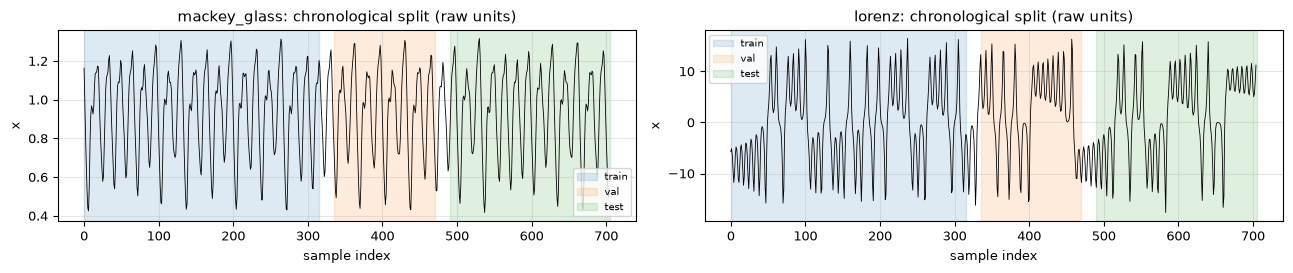

In [3]:
def mackey_glass(n, seed, beta=0.2, gamma=0.1, n_exp=10, tau=17.0, dt=0.1, every=30, transient=3000.0):
    rng = np.random.default_rng(seed); H = int(round(tau / dt)); n_tr = int(round(transient / dt)); total = n_tr + n * every + 1
    x = np.empty(total + H); x[:H + 1] = rng.uniform(0.5, 1.3) + rng.uniform(-0.05, 0.05, H + 1)
    f = lambda a, ad: beta * ad / (1.0 + ad ** n_exp) - gamma * a
    for i in range(H, total + H - 1):
        d0, d1 = x[i - H], x[i - H + 1]; dm = 0.5 * (d0 + d1); xi = x[i]
        k1 = f(xi, d0); k2 = f(xi + .5 * dt * k1, dm); k3 = f(xi + .5 * dt * k2, dm); k4 = f(xi + dt * k3, d1)
        x[i + 1] = xi + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return x[H + n_tr::every][:n]


def lorenz_x(n, seed, sigma=10.0, rho=28.0, beta=8 / 3, dt=0.01, every=10, transient=60.0):
    rng = np.random.default_rng(seed); X, Y, Z = rng.normal(0, 8, 3) + np.array([0.0, 0.0, 25.0])
    f = lambda x, y, z: (sigma * (y - x), x * (rho - z) - y, x * y - beta * z)
    n_tr = int(round(transient / dt)); out = np.empty(n); k = 0
    for i in range(n_tr + n * every):
        a1 = f(X, Y, Z); a2 = f(X + .5 * dt * a1[0], Y + .5 * dt * a1[1], Z + .5 * dt * a1[2])
        a3 = f(X + .5 * dt * a2[0], Y + .5 * dt * a2[1], Z + .5 * dt * a2[2]); a4 = f(X + dt * a3[0], Y + dt * a3[1], Z + dt * a3[2])
        X += dt / 6 * (a1[0] + 2 * a2[0] + 2 * a3[0] + a4[0]); Y += dt / 6 * (a1[1] + 2 * a2[1] + 2 * a3[1] + a4[1]); Z += dt / 6 * (a1[2] + 2 * a2[2] + 2 * a3[2] + a4[2])
        if i >= n_tr and (i - n_tr) % every == 0:
            out[k] = X; k += 1
    return out


DATASETS = ('mackey_glass', 'lorenz')
SEG = {sp: D - 1 + CFG[f'n_{sp}'] + HMAX for sp in ('train', 'val', 'test')}
START = {'train': 0, 'val': SEG['train'] + CFG['gap'], 'test': SEG['train'] + CFG['gap'] + SEG['val'] + CFG['gap']}
L_TOTAL = START['test'] + SEG['test']
SERIES, NORM, ORIG = {}, {}, {}
for i, ds in enumerate(DATASETS):
    x = (mackey_glass if ds == 'mackey_glass' else lorenz_x)(L_TOTAL, np.random.SeedSequence([GLOBAL_SEED, i]))
    lo, hi = x[:SEG['train']].min(), x[:SEG['train']].max()                     # training segment only
    SERIES[ds], NORM[ds] = x, (float(lo), float(hi))
    ORIG[ds] = {sp: START[sp] + D - 1 + np.arange(CFG[f'n_{sp}']) for sp in START}   # forecast origins


def xn(ds, v):
    lo, hi = NORM[ds]; return 2 * (np.asarray(v) - lo) / (hi - lo) - 1


def xinv(ds, v):
    lo, hi = NORM[ds]; return (np.asarray(v) + 1) / 2 * (hi - lo) + lo


def windows_of(ds, sp):
    t = ORIG[ds][sp]; return np.stack([xn(ds, SERIES[ds][t - D + 1 + k]) for k in range(D)], 1)   # oldest -> newest


def targets_of(ds, sp, h):
    return SERIES[ds][ORIG[ds][sp] + h]


for ds in DATASETS:
    for sp in START:
        t = ORIG[ds][sp]
        assert t.min() - (D - 1) >= START[sp] and t.max() + HMAX < START[sp] + SEG[sp], 'window/target crosses a partition'
    out_frac = {sp: float(np.mean(np.abs(xn(ds, SERIES[ds][START[sp]:START[sp] + SEG[sp]])) > 1)) for sp in ('val', 'test')}
    print(f"{ds}: length {L_TOTAL}, train origins {ORIG[ds]['train'][[0, -1]]}, val {ORIG[ds]['val'][[0, -1]]}, test {ORIG[ds]['test'][[0, -1]]}; "
          f"norm (train) [{NORM[ds][0]:.3f}, {NORM[ds][1]:.3f}]; fraction of val/test values outside the train range {out_frac}")
fig, ax = plt.subplots(1, 2, figsize=(13, 2.8))
for a, ds in zip(ax, DATASETS):
    a.plot(SERIES[ds], lw=0.6, c='k')
    for sp, c in (('train', 'C0'), ('val', 'C1'), ('test', 'C2')):
        a.axvspan(START[sp], START[sp] + SEG[sp], color=c, alpha=0.15, label=sp)
    a.set_title(f'{ds}: chronological split (raw units)'); a.set_xlabel('sample index'); a.set_ylabel('x'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 4. Existing-notebook architecture audit

Notebooks 4 and 6 were inspected.
- **The EOC circuit family is notebook 4's `mixed_layer`:**
  - nearest-neighbour $R_{xx}+R_{yy}$ hopping $g$ (SYK2-like);
  - sparse random-Pauli-type 4-body rotations with $J\sim\mathcal N(0,J)$ (SYK4-like);
  - an $R_z$ disorder kick;
  - with $g(\kappa)=G_{\max}\kappa/(1+\kappa)$ and $J(\kappa)=J_{\max}/(1+\kappa)$, $G_{\max}=\pi/2$, $J_{\max}=1$;
  - `reps` Floquet layers per input step, as notebook 4's discrete-time "Trotter" convention.
- **The EOC diagnostic** is notebook 4's adjacent-gap ratio $\langle r\rangle$ against numerically calibrated
  Poisson/COE/CUE references, with operator entanglement and the OTOC scrambling time.
- **Runtime extraction.** These definitions (and notebook 1's `ReservoirConfig` / `make_simulator`) are parsed out of
  the source notebooks with `ast` and executed here, unchanged.

**One necessary, disclosed adaptation.** This reservoir has only **4 qubits** (A–D). Notebook 4's sampler draws
$\lceil N\ln N\rceil=6$ quartic terms *without replacement* over 4-qubit tuples, and $\binom44=1$, so it returns a
single quartic Pauli string, which commutes with itself. The cell below shows that this degenerate family is *never*
chaotic at N = 4: ⟨r⟩ stays far below the CUE value. There is then no edge of chaos to calibrate.

The minimal generalisation used here is to draw the 6 terms *with replacement* over tuples whenever
$\binom N4<n_{\rm terms}$. Each term keeps notebook 4's independent random Pauli types and Gaussian couplings. For
$\binom N4\ge n_{\rm terms}$ (every N ≥ 6) it calls notebook 4's sampler unchanged, which is checked below. With this
fix the 4-qubit family has a genuine chaotic window and an integrable limit.

In [4]:
def extract_defs(path, names):
    nb = json.load(open(path, encoding='utf-8')); found = {}
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        src = ''.join(cell['source'])
        try:
            tree = ast.parse(src)
        except SyntaxError:
            continue
        lines = src.splitlines()
        for node in tree.body:
            if isinstance(node, (ast.FunctionDef, ast.ClassDef)):
                nm = node.name
            elif isinstance(node, ast.Assign) and len(node.targets) == 1 and isinstance(node.targets[0], ast.Name):
                nm = node.targets[0].id
            else:
                continue
            if nm in names and nm not in found:
                start = min([d.lineno for d in getattr(node, 'decorator_list', [])] + [node.lineno])
                found[nm] = '\n'.join(lines[start - 1:node.end_lineno])
    missing = set(names) - set(found); assert not missing, f'{path}: missing {missing}'
    return found


NB1_NAMES = ['chain_edges', 'ReservoirConfig', 'make_simulator']
NB4_NAMES = ['default_n_sparse_terms', 'sample_syk4_terms', 'sample_syk4_couplings', 'sample_syk4_pauli_types', 'zzzz_rotation',
             '_basis_change_pre', '_basis_change_post', 'pauli4_rotation', 'mixed_layer', 'kappa_to_gJ',
             'single_layer_unitary_mixed', 'operator_entanglement', 'level_spacing_ratio', 'sample_reference_r_statistics',
             '_local_pauli', 'otoc_curve', 'scrambling_time']
EXTRACTED = {}
for path, names in ((SOURCES[0], NB1_NAMES), (SOURCES[1], NB4_NAMES)):
    defs = extract_defs(path, names)
    for nm in names:
        exec(compile(defs[nm], f'<{path}:{nm}>', 'exec'), globals())
        EXTRACTED[nm] = (path, hashlib.sha256(defs[nm].encode()).hexdigest()[:12])
for nm, (p, h) in EXTRACTED.items():
    print(f'{nm:30s} <- {p:28s} sha {h}')
assert not any(m.startswith('klqrc') for m in sys.modules), 'helper modules of notebook 5 must not be imported'
G_MAX, J_MAX = np.pi / 2, 1.0


def quartic_terms(N, n_terms, seed):
    """Notebook 4's sampler when C(N,4) >= n_terms; otherwise draw tuples WITH replacement (seeded)."""
    if n_terms <= comb(N, 4):
        return sample_syk4_terms(N, n_terms, seed)
    tup = list(itertools.combinations(range(N), 4))
    return [tup[i] for i in np.random.RandomState(seed).choice(len(tup), size=n_terms, replace=True)]


assert all(quartic_terms(6, default_n_sparse_terms(6), s) == sample_syk4_terms(6, default_n_sparse_terms(6), s) for s in range(5))


def layer_U(N, kappa, seed, sampler):
    g, J = kappa_to_gJ(float(kappa), G_MAX, J_MAX); n = default_n_sparse_terms(N)
    return single_layer_unitary_mixed(N, g, sampler(N, n, seed), sample_syk4_couplings(n, J, seed), sample_syk4_pauli_types(n, seed),
                                      ReservoirConfig(N=N, seed=seed).sample_disorder()[0])


print('\nN=4 gap ratio <r> (median over 100 disorder seeds), CUE ~0.60, Poisson ~0.39:')
for k in (0.1, 0.7, 3.0, 20.0):
    a = np.median([level_spacing_ratio(layer_U(4, k, s, sample_syk4_terms)) for s in range(100)])
    b = np.median([level_spacing_ratio(layer_U(4, k, s, quartic_terms)) for s in range(100)])
    print(f'  kappa={k:5.1f}: notebook-4 sampler (single quartic term) {a:.3f} | with-replacement sampler {b:.3f}')
nb6 = json.load(open(SOURCES[3], encoding='utf-8'))
for c in nb6['cells']:
    for o in c.get('outputs', []):
        t = ''.join(o.get('data', {}).get('text/markdown', ''))
        if t.startswith('### Outcome'):
            print('\nnotebook 6 >', t.splitlines()[0])

chain_edges                    <- 1_QR_Qiskit.ipynb            sha fe98f6401104
ReservoirConfig                <- 1_QR_Qiskit.ipynb            sha fd42b609eaa8
make_simulator                 <- 1_QR_Qiskit.ipynb            sha 6ed38a4895a1
default_n_sparse_terms         <- 4_QR_MixedSYK_Qiskit.ipynb   sha 107af239cb91
sample_syk4_terms              <- 4_QR_MixedSYK_Qiskit.ipynb   sha 06542200a727
sample_syk4_couplings          <- 4_QR_MixedSYK_Qiskit.ipynb   sha 3ddd35f76470
sample_syk4_pauli_types        <- 4_QR_MixedSYK_Qiskit.ipynb   sha 727e3ac8b57d
zzzz_rotation                  <- 4_QR_MixedSYK_Qiskit.ipynb   sha ae01641e29d1
_basis_change_pre              <- 4_QR_MixedSYK_Qiskit.ipynb   sha 9241caba3fdd
_basis_change_post             <- 4_QR_MixedSYK_Qiskit.ipynb   sha 0291044d686c
pauli4_rotation                <- 4_QR_MixedSYK_Qiskit.ipynb   sha c2f4a35588a0
mixed_layer                    <- 4_QR_MixedSYK_Qiskit.ipynb   sha 1a64806611ad
kappa_to_gJ                    <- 4_QR_M

  kappa=  0.1: notebook-4 sampler (single quartic term) 0.397 | with-replacement sampler 0.498


  kappa=  0.7: notebook-4 sampler (single quartic term) 0.410 | with-replacement sampler 0.591


  kappa=  3.0: notebook-4 sampler (single quartic term) 0.396 | with-replacement sampler 0.510


  kappa= 20.0: notebook-4 sampler (single quartic term) 0.358 | with-replacement sampler 0.390

notebook 6 > ### Outcome: **2. Interface repaired, EOC not beaten**


## 5. Quantum history encoder

**Feature map.** $U_X(\tilde x)$ is a shallow data-re-uploading map on the reservoir qubits A–D:
- $R_y(a_q\tilde x+b_q)R_z(c_q\tilde x+d_q)$ on each qubit $q$;
- then a fixed CX chain A→B→C→D;
- the coefficients are seeded and deterministic per model seed;
- the slopes $a_q,c_q=s\cdot U(0.5,1)\pi$ carry an **encoder scale** $s\in\{0.125,0.25,0.5\}$, selected on validation
  together with the EOC operating point (§6). In development, $s=1$, i.e. angles of up to ~2π per step compounded over
  6 chaotic steps, made every readout nearly uninformative.

**Primary history circuit (hardware-executable, no state initialisation).**

$$|\psi_t\rangle=\prod_{k=t-d+1}^{t}\left[U_{\rm EOC}\,U_X(x_k)\right]|0\rangle_{ABCD},$$

ordered oldest → newest. Only $x_{t-d+1},\dots,x_t$ enter, so no future value can appear.

**Why this is a quantum feature encoder.** $X_t\mapsto\rho(X_t)$ embeds the history in a $2^4$-dimensional operator
space. Every readout below is a *linear functional* of that embedded state, possibly jointly with an ancilla state,
i.e. a kernel-type inner product $\mathrm{Tr}[\rho(X_t)M]$. No pairwise kernel matrix is ever formed.

**Ablation.** "One-shot" window encoding applies $U_X(x_{t-d+1})\cdots U_X(x_t)$ first and then $d$ EOC blocks
(matched depth).

The template is a `ParameterVector` circuit, bound per history through Aer `parameter_binds`.

In [5]:
XP = ParameterVector('x', D)
ORDER_PERM = tuple(np.random.default_rng([GLOBAL_SEED, 99]).permutation(D))   # fixed permutation for the shuffled-order ablation


def enc_coeffs(seed, scale=1.0):
    """Seeded re-uploading coefficients; the input slopes a, c are multiplied by the validation-selected encoder scale."""
    rng = np.random.default_rng([GLOBAL_SEED, 1, seed])
    return {k: (scale * rng.uniform(0.5, 1.0, N_RES) * np.pi if k in 'ac' else rng.uniform(0, np.pi, N_RES)) for k in 'abcd'}


def apply_UX(qc, x, cf):
    for i, q in enumerate(RES):
        qc.ry(cf['a'][i] * x + cf['b'][i], q); qc.rz(cf['c'][i] * x + cf['d'][i], q)
    for q0, q1 in zip(RES[:-1], RES[1:]):
        qc.cx(q0, q1)


@dataclass(frozen=True)
class ResCfg:
    kappa: float
    reps: int
    seed: int
    mode: str = 'eoc'           # 'eoc' | 'none' (identity reservoir)
    scale: float = 1.0          # encoder input scale (selected on validation together with kappa, reps)


@functools.lru_cache(maxsize=None)
def eoc_block(res):
    sub = QuantumCircuit(N_RES, name='U_EOC')
    if res.mode == 'none':
        return sub
    g, J = kappa_to_gJ(float(res.kappa), G_MAX, J_MAX); n = default_n_sparse_terms(N_RES)
    terms, cps, pts = quartic_terms(N_RES, n, res.seed), sample_syk4_couplings(n, J, res.seed), sample_syk4_pauli_types(n, res.seed)
    bz = ReservoirConfig(N=N_RES, seed=res.seed).sample_disorder()[0]
    for _ in range(res.reps):
        mixed_layer(sub, N_RES, g, terms, cps, pts, bz)
    return sub


PAULIS1 = [(P, [q]) for q in RES for P in 'XYZ']
PAULIS2 = [(Pi + Pj, [i, j]) for i, j in itertools.combinations(RES, 2) for Pi in 'XYZ' for Pj in 'XYZ']   # label char k acts on qubit k
B2_OBS = PAULIS1 + PAULIS2
B1_IDX = [k for k, (P, qs) in enumerate(B2_OBS) if set(P) == {'Z'}]                                    # Z_q and Z_iZ_j
L9 = [(0, 0, 0, 0), (0, 1, 1, 1), (0, 2, 2, 2), (1, 0, 1, 2), (1, 1, 2, 0), (1, 2, 0, 1), (2, 0, 2, 1), (2, 1, 0, 2), (2, 2, 1, 0)]


@functools.lru_cache(maxsize=None)
def history_template(res, enc_seed, mode='seq', save='dm', setting=None):
    """mode: 'seq' (primary) | 'oneshot' | 'ordershuf'.  save: 'dm' (exact DM + Pauli expectations) | 'meas' (shots,
    optional basis setting for B2)."""
    qc = QuantumCircuit(N_TOT); cf = enc_coeffs(enc_seed, res.scale); blk = eoc_block(res)
    order = list(ORDER_PERM) if mode == 'ordershuf' else list(range(D))
    if mode == 'oneshot':
        for k in order:
            apply_UX(qc, XP[k], cf)
        for _ in order:
            qc.compose(blk, qubits=RES, inplace=True)
    else:
        for k in order:
            apply_UX(qc, XP[k], cf); qc.compose(blk, qubits=RES, inplace=True)
    if save == 'dm':
        qc.save_density_matrix(label='rho')
        for k, (P, qs) in enumerate(B2_OBS):
            qc.save_expectation_value(Pauli(P[::-1]), qs, label=f'o{k}')     # Pauli label is big-endian
    else:
        if setting is not None:
            for q, b in zip(RES, setting):
                if b == 0: qc.h(q)
                elif b == 1: qc.sdg(q); qc.h(q)
        qc.measure_all()
    return qc


STATS = {'experiments': 0, 'circuits': 0, 'aer_seconds': 0.0, 'by_tag': {}}
SIM_EXACT = AerSimulator(method='density_matrix', device=DEVICE, max_parallel_experiments=max(1, min(6, (os.cpu_count() or 2) // 2)))
assert SIM_EXACT.options.method == 'density_matrix'


def aer_run(circs, binds, tag, shots=None, seed=None):
    """Batched Aer execution; returns the flat list of per-experiment data dicts (circuit-major, binding-minor)."""
    out = []
    for i in range(0, len(circs), CFG['chunk']):
        cs, bs = circs[i:i + CFG['chunk']], binds[i:i + CFG['chunk']]
        kw = {'shots': shots or 1}
        if seed is not None:
            kw['seed_simulator'] = int(seed + i)
        t0 = time.perf_counter()
        res = SIM_EXACT.run(cs, parameter_binds=bs, **kw).result()
        dt = time.perf_counter() - t0
        assert res.success and res.backend_name.startswith('aer_simulator'), res.status
        n = len(res.results)
        out += [res.data(j) if shots is None else res.get_counts(j) for j in range(n)]
        STATS['experiments'] += n; STATS['circuits'] += len(cs); STATS['aer_seconds'] += dt
        STATS['by_tag'][tag] = STATS['by_tag'].get(tag, 0) + n
    return out


def run_histories(res, enc_seed, ds, mode='seq'):
    """Exact Aer density-matrix history runs for all splits: rho (6-qubit) and the 66 Pauli expectations."""
    tpl = history_template(res, enc_seed, mode)
    out = {}
    for sp in ('train', 'val', 'test'):
        W = windows_of(ds, sp)
        data = aer_run([tpl], [{XP[k]: list(W[:, k]) for k in range(D)}], tag='history')
        out[sp] = {'rho': [np.asarray(d_['rho'].data if hasattr(d_['rho'], 'data') else d_['rho']) for d_ in data],
                   'obs': np.array([[np.real(d_[f'o{k}']) for k in range(len(B2_OBS))] for d_ in data])}
    return out


def history_plain(res, enc_seed, w, mode='seq'):
    """Concrete (bound) hardware-executable history circuit for one window w (oldest -> newest), no save instructions."""
    qc = QuantumCircuit(N_TOT); cf = enc_coeffs(enc_seed, res.scale); blk = eoc_block(res)
    for k in range(D):
        apply_UX(qc, float(w[k]), cf); qc.compose(blk, qubits=RES, inplace=True)
    return qc


tq = transpile(history_plain(ResCfg(1.0, 2, 0), 0, 0.1 * np.arange(D)), basis_gates=['rz', 'sx', 'x', 'cx'], optimization_level=1)
print(f'history circuit (d={D}, reps=2): depth {tq.depth()}, CX count {tq.count_ops().get("cx", 0)}, {len(B2_OBS)} saved Pauli observables '
      f'({len(B1_IDX)} of them are the B1 Z/ZZ set)')

history circuit (d=6, reps=2): depth 1088, CX count 546, 66 saved Pauli observables (10 of them are the B1 Z/ZZ set)


## 6. EOC reservoir and EOC calibration

**Diagnostic (training-free).** Over a dense κ grid and 300 disorder seeds, the single-layer Floquet operator gives:
- ⟨r⟩ against Poisson/CUE references calibrated at $d=2^4$;
- the operator entanglement of the `reps`-fold step operator;
- the OTOC scrambling time.

**Edge band.** Let $\eta=(\langle r\rangle-r_P)/(r_{\rm CUE}-r_P)$ (median over seeds).
- $\kappa_{\rm lo}$ is the largest κ with $\eta\ge0.9$.
- $\kappa_{\rm hi}$ is the first larger κ with $\eta\le0.1$.

**Operating point (training/validation only).** Candidates are 3 log-spaced κ in the band × `reps` ∈ {1, 2, 3} ×
encoder scale ∈ {0.125, 0.25, 0.5}.
- The selection score is the *validation* NRMSE of the standard EOC readout (B1, ridge on Z/ZZ), averaged over
  horizons, median over model seeds.
- Selection is per dataset.
- The selected (κ, reps) is then used, unchanged, by **every** EOC-based model.

**Away-from-EOC (B6).**
- *Stable*: κ = 100 (integrable side).
- *More chaotic*: the arg-max of ⟨r⟩. It is skipped if that point lies within ±10 % of the selected κ.

refs at d=16: Poisson 0.387, COE 0.531, CUE 0.601
EDGE BAND: kappa in [0.992, 16.958]  (band points [ 0.992  4.101 16.958]); most chaotic kappa 0.695; diagnostics 53s


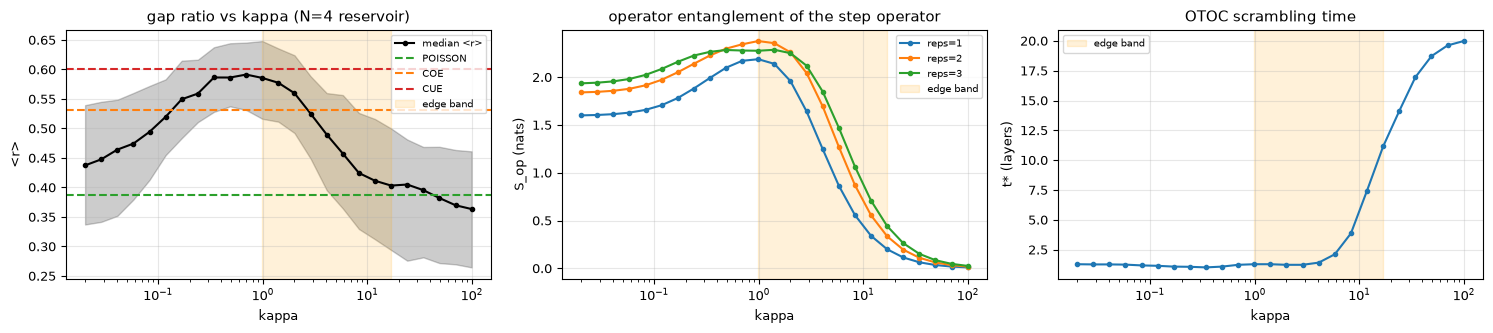

In [6]:
t0 = time.perf_counter()
REFS = sample_reference_r_statistics(2 ** N_RES, trials=2000, seed=0)
KD = np.array(CFG['kappa_dense'])
R_DIAG = np.array([[level_spacing_ratio(layer_U(N_RES, k, s, quartic_terms)) for s in range(CFG['diag_seeds'])] for k in KD])
SOP = {r_: np.array([np.mean([operator_entanglement(np.linalg.matrix_power(layer_U(N_RES, k, s, quartic_terms), r_), N_RES)
                             for s in range(min(60, CFG['diag_seeds']))]) for k in KD]) for r_ in CFG['reps_grid']}
TSTAR = np.array([np.mean([scrambling_time(layer_U(N_RES, k, s, quartic_terms), N_RES, 0, N_RES - 1)[0] for s in range(min(60, CFG['diag_seeds']))]) for k in KD])
r_med = np.median(R_DIAG, 1)
ETA = (r_med - REFS['poisson'][0]) / (REFS['cue'][0] - REFS['poisson'][0])
hi_ = np.where(ETA >= 0.9)[0]; i_lo = int(hi_.max()) if len(hi_) else int(np.argmax(ETA))
lo_ = np.where((np.arange(len(KD)) > i_lo) & (ETA <= 0.1))[0]; i_hi = int(lo_.min()) if len(lo_) else len(KD) - 1
K_LO, K_HI = float(KD[i_lo]), float(KD[i_hi])
BAND_PTS = tuple(float(k) for k in np.geomspace(K_LO, K_HI, CFG['n_band']))
K_MAXCHAOS = float(KD[int(np.argmax(r_med))])
print(f"refs at d={2 ** N_RES}: Poisson {REFS['poisson'][0]:.3f}, COE {REFS['coe'][0]:.3f}, CUE {REFS['cue'][0]:.3f}")
print(f'EDGE BAND: kappa in [{K_LO:.3f}, {K_HI:.3f}]  (band points {np.round(BAND_PTS, 3)}); most chaotic kappa {K_MAXCHAOS:.3f}; '
      f'diagnostics {time.perf_counter() - t0:.0f}s')
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
q = np.percentile(R_DIAG, [25, 50, 75], 1)
ax[0].plot(KD, q[1], 'k.-', label='median <r>'); ax[0].fill_between(KD, q[0], q[2], alpha=0.2, color='k')
for nm, c in (('poisson', 'C2'), ('coe', 'C1'), ('cue', 'C3')):
    ax[0].axhline(REFS[nm][0], ls='--', c=c, label=nm.upper())
for r_ in CFG['reps_grid']:
    ax[1].plot(KD, SOP[r_], 'o-', ms=3, label=f'reps={r_}')
ax[2].plot(KD, TSTAR, 'o-', ms=3)
for a, t, yl in zip(ax, ('gap ratio vs kappa (N=4 reservoir)', 'operator entanglement of the step operator', 'OTOC scrambling time'),
                    ('<r>', 'S_op (nats)', 't* (layers)')):
    a.axvspan(K_LO, K_HI, color='orange', alpha=0.15, label='edge band'); a.set_xscale('log'); a.set_xlabel('kappa'); a.set_ylabel(yl); a.set_title(t)
    a.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [7]:
def ridge_val(Ftr, ytr, Fva, yva, alphas=CFG['ridge_alphas']):
    sc = StandardScaler().fit(Ftr); best = None
    for a in alphas:
        m = Ridge(alpha=a).fit(sc.transform(Ftr), ytr); e = nrmse(m.predict(sc.transform(Fva)), yva)
        if best is None or e < best[0]:
            best = (e, a)
    m = Ridge(alpha=best[1]).fit(sc.transform(Ftr), ytr)
    return m, sc, best[1], best[0]


def nrmse(p, y):
    return float(np.sqrt(np.mean((np.asarray(p) - np.asarray(y)) ** 2)) / (np.std(y) + 1e-12))


t0 = time.perf_counter()
CAL = {}
for ds in DATASETS:
    for k in BAND_PTS:
      for r_ in CFG['reps_grid']:
        for sc_ in CFG['enc_scales']:
            per_seed = []
            for s in SEEDS:
                H = run_histories(ResCfg(k, r_, s, 'eoc', sc_), s, ds)
                errs = []
                for h in HZ:
                    _, _, _, e = ridge_val(H['train']['obs'][:, B1_IDX], targets_of(ds, 'train', h), H['val']['obs'][:, B1_IDX], targets_of(ds, 'val', h))
                    errs.append(e)
                per_seed.append(np.mean(errs))
            CAL[(ds, k, r_, sc_)] = float(np.median(per_seed))
EOC_SEL = {ds: min(((k, r_, sc_) for k in BAND_PTS for r_ in CFG['reps_grid'] for sc_ in CFG['enc_scales']), key=lambda c: CAL[(ds, *c)]) for ds in DATASETS}
for ds in DATASETS:
    print(f'{ds}: validation B1 NRMSE (mean over h, median over seeds): ' + ', '.join(f'k={k:.2f},r={r_},s={sc_}: {CAL[(ds, k, r_, sc_)]:.4f}' for k in BAND_PTS for r_ in CFG['reps_grid'] for sc_ in CFG['enc_scales']))
    print(f'   SELECTED: kappa={EOC_SEL[ds][0]:.4f}, reps={EOC_SEL[ds][1]}, encoder scale={EOC_SEL[ds][2]} (kappa inside band [{K_LO:.3f},{K_HI:.3f}])')
print(f'EOC calibration: {time.perf_counter() - t0:.0f}s (training/validation data only)')

mackey_glass: validation B1 NRMSE (mean over h, median over seeds): k=0.99,r=1,s=0.125: 0.2267, k=0.99,r=1,s=0.25: 0.3590, k=0.99,r=1,s=0.5: 0.6982, k=0.99,r=2,s=0.125: 0.2508, k=0.99,r=2,s=0.25: 0.3747, k=0.99,r=2,s=0.5: 0.7472, k=0.99,r=3,s=0.125: 0.2129, k=0.99,r=3,s=0.25: 0.3410, k=0.99,r=3,s=0.5: 0.6365, k=4.10,r=1,s=0.125: 0.2578, k=4.10,r=1,s=0.25: 0.4022, k=4.10,r=1,s=0.5: 0.6594, k=4.10,r=2,s=0.125: 0.2561, k=4.10,r=2,s=0.25: 0.3451, k=4.10,r=2,s=0.5: 0.6537, k=4.10,r=3,s=0.125: 0.2208, k=4.10,r=3,s=0.25: 0.4820, k=4.10,r=3,s=0.5: 0.7633, k=16.96,r=1,s=0.125: 0.2964, k=16.96,r=1,s=0.25: 0.3824, k=16.96,r=1,s=0.5: 0.6255, k=16.96,r=2,s=0.125: 0.2521, k=16.96,r=2,s=0.25: 0.3591, k=16.96,r=2,s=0.5: 0.6992, k=16.96,r=3,s=0.125: 0.2257, k=16.96,r=3,s=0.25: 0.3750, k=16.96,r=3,s=0.5: 0.6761
   SELECTED: kappa=0.9917, reps=3, encoder scale=0.125 (kappa inside band [0.992,16.958])
lorenz: validation B1 NRMSE (mean over h, median over seeds): k=0.99,r=1,s=0.125: 0.7963, k=0.99,r=1,s=0.

## 7. Direct measurement head

After the final EOC block, qubits $R_{\rm direct}=\{A,B\}$ are measured in the computational basis. Their outcome
distribution $p_{AB}(a,b\mid X_t)$ and the derived $\langle Z_A\rangle,\langle Z_B\rangle,\langle Z_AZ_B\rangle$ are
part of the joint distribution recovered from each candidate circuit.

These features are candidate-independent, and that is audited. In the linear conditional-logit scorer a purely
history-dependent feature cancels in the softmax over candidates, so the direct branch acts through its explicit
interactions with the candidate coordinate, $\tilde y\,p_{AB}$ and $\tilde y^2p_{AB}$.

**What the split costs.** Measuring A, B locally discards the coherences between {A, B} and {C, D}. Any predictive
information stored *only* in cross-partition coherences, i.e. correlators with off-diagonal components on both
sides, becomes inaccessible to both heads. Only classical correlations between the two branches survive in the joint
distribution. A purely local readout of a scrambled reservoir pays exactly this price.

## 8. Candidate/reference encoder

$|\phi_Y(y)\rangle_{EF}=U_Y(\tilde y)|00\rangle$ is built as follows:
- $R_y(\alpha_1\tilde y)R_z(\beta_1\tilde y)$ on E and $R_y(\alpha_2\tilde y)R_z(\beta_2\tilde y)$ on F;
- then CX(E→F);
- $\tilde y$ is the train-normalised candidate.

The candidate grid covers training targets only: the 0.5–99.5 percentile range of all training targets, ± 2 %, with
21 coarse points. Frequencies are tried in a fixed order, and the first set without **aliasing** is kept. Aliasing
means a pair of grid values more than 2 spacings apart with fidelity > 0.95.

This uses the training-derived grid only, and the encoding is frozen before any forecasting. The ablation uses a
simpler one-qubit encoding (E only).

mackey_glass: grid [-1.021, 1.023] (21 pts); frequencies [[1.571, 3.142], [1.047, 2.094]]; off-diagonal fidelity min 0.001 / median 0.446 / max 0.968; max fidelity for pairs >2 spacings apart 0.769
lorenz: grid [-1.040, 1.027] (21 pts); frequencies [[1.571, 3.142], [1.047, 2.094]]; off-diagonal fidelity min 0.001 / median 0.448 / max 0.968; max fidelity for pairs >2 spacings apart 0.777


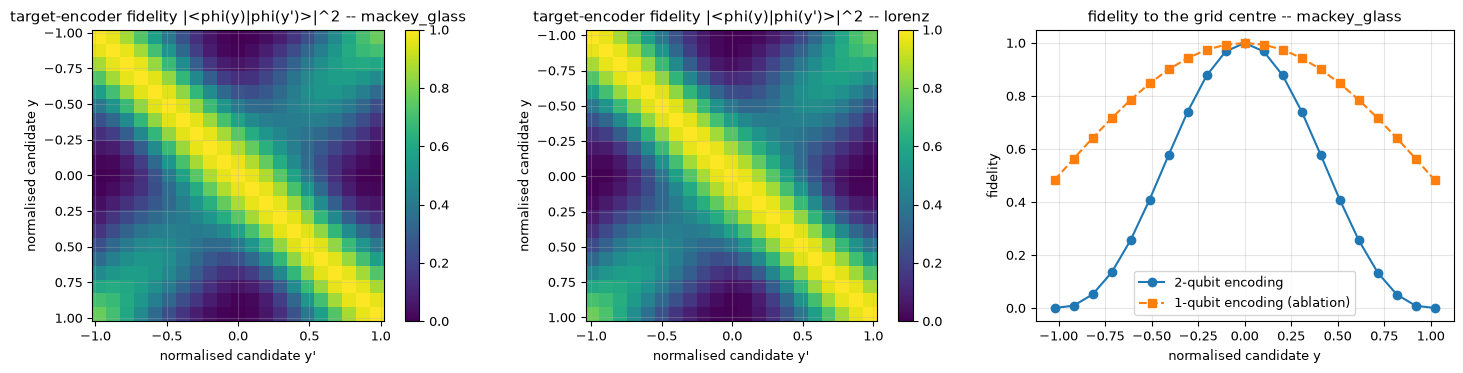

In [8]:
YP = Parameter('y')
FREQ_SETS = [((np.pi / 2, np.pi), (np.pi / 3, 2 * np.pi / 3)), ((np.pi / 2, 3 * np.pi / 4), (np.pi / 4, np.pi / 2)),
             ((np.pi / 3, 2 * np.pi / 3), (np.pi / 4, np.pi / 3))]
GRID = {}
for ds in DATASETS:
    yt = xn(ds, np.concatenate([targets_of(ds, 'train', h) for h in HZ]))
    lo, hi = np.percentile(yt, [0.5, 99.5]); m = 0.02 * (hi - lo)
    GRID[ds] = np.linspace(lo - m, hi + m, CFG['n_coarse'])


def apply_UY(qc, yv, freqs, cand='2q'):
    (a1, a2), (b1, b2) = freqs
    qc.ry(a1 * yv, REF[0]); qc.rz(b1 * yv, REF[0])
    if cand == '2q':
        qc.ry(a2 * yv, REF[1]); qc.rz(b2 * yv, REF[1]); qc.cx(REF[0], REF[1])


def target_states(ys, freqs, cand='2q'):
    qc = QuantumCircuit(N_TOT); apply_UY(qc, YP, freqs, cand); qc.save_statevector()
    sim = AerSimulator(method='statevector')
    res = sim.run([qc], parameter_binds=[{YP: list(ys)}]).result()
    return np.array([np.asarray(res.data(i)['statevector']) for i in range(len(ys))])


def fidelity_matrix(ys, freqs, cand='2q'):
    S = target_states(ys, freqs, cand); return np.abs(S.conj() @ S.T) ** 2


FREQ, FID = {}, {}
for ds in DATASETS:
    g = GRID[ds]; sp_ = g[1] - g[0]
    far = np.abs(g[:, None] - g[None]) > 2 * sp_ + 1e-12
    for fs in FREQ_SETS:
        Fm = fidelity_matrix(g, fs)
        if Fm[far].max() <= 0.95:
            FREQ[ds], FID[ds] = fs, Fm; break
    else:
        FREQ[ds] = FREQ_SETS[0]; FID[ds] = fidelity_matrix(g, FREQ[ds]); print(f'** {ds}: no alias-free frequency set; using the first **')
    off = FID[ds][~np.eye(len(g), dtype=bool)]
    print(f"{ds}: grid [{g[0]:.3f}, {g[-1]:.3f}] ({len(g)} pts); frequencies {np.round(FREQ[ds], 3).tolist()}; off-diagonal fidelity "
          f"min {off.min():.3f} / median {np.median(off):.3f} / max {off.max():.3f}; max fidelity for pairs >2 spacings apart {FID[ds][far].max():.3f}")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, ds in zip(ax[:2], DATASETS):
    im = a.imshow(FID[ds], extent=[GRID[ds][0], GRID[ds][-1], GRID[ds][-1], GRID[ds][0]], cmap='viridis', vmin=0, vmax=1)
    a.set_title(f'target-encoder fidelity |<phi(y)|phi(y\')>|^2 -- {ds}'); a.set_xlabel("normalised candidate y'"); a.set_ylabel('normalised candidate y')
    plt.colorbar(im, ax=a)
F1 = fidelity_matrix(GRID[DATASETS[0]], FREQ[DATASETS[0]], '1q')
ax[2].plot(GRID[DATASETS[0]], FID[DATASETS[0]][CFG['n_coarse'] // 2], 'o-', label='2-qubit encoding')
ax[2].plot(GRID[DATASETS[0]], F1[CFG['n_coarse'] // 2], 's--', label='1-qubit encoding (ablation)')
ax[2].set_title(f'fidelity to the grid centre -- {DATASETS[0]}'); ax[2].set_xlabel('normalised candidate y'); ax[2].set_ylabel('fidelity'); ax[2].legend()
plt.tight_layout(); plt.show()

## 9. Destructive-SWAP similarity: implementation and validation

**Circuit.** For each pair $(C,E)$ and $(D,F)$: CX(sim → ref), H(sim), then measure both.
- **Local eigenvalue.** $s_k=-1$ if the pair outcome is 11, else $+1$.
- **Global estimator.** $s=s_1s_2$, with
  $\mathbb E[s]=\mathrm{Tr}[(\rho_{CD}\otimes\sigma_{EF})\,\mathrm{SWAP}_{CE}\mathrm{SWAP}_{DF}]=\mathrm{Tr}[\rho_{CD}\sigma_{EF}]$.

**Generalised measurement.** Ancilla preparation, the joint unitary (CX, H) and the computational-basis measurement
together implement, by Naimark dilation, a *POVM* on the reservoir subsystem C, D. Its effects
$M_{z}(y)=\mathrm{Tr}_{EF}[(I\otimes\sigma(y))\,U^\dagger|z\rangle\langle z|U]$ depend on the candidate. The ancillas
carry only the *candidate*; they add no information about the target, because data-processing applies to
$\rho_{CD}$. What they can change is *which* functional of $\rho_{CD}$ is estimated, and the overlap with a
candidate-dependent state is such a functional.

**Tests** (they raise on failure):
1. identical random pure states give overlap 1;
2. orthogonal states give 0;
3. $|00\rangle$ vs $|{+}{+}\rangle$ gives 1/4;
4. a random mixed $\rho_{CD}$ against a random pure σ matches the analytic $\mathrm{Tr}[\rho\sigma]$;
5. 4096-shot estimates agree with the exact value within 4 σ.

**Deferred vs immediate measurement of A, B.** The similarity operations act only on C, D, E, F, and there is no
feedforward, so measuring A, B first commutes with everything that follows. The joint statistics are identical; this
is checked numerically with 200k shots.

**State reuse.** For simulation efficiency, each candidate circuit starts from the *exact* Aer history density
matrix (`set_density_matrix`). This is checked against the full **hardware-realisable** replay, which has no state
initialisation, to $10^{-10}$. Hardware cost estimates (§19) count the full replay of the history for every candidate,
because an unknown state cannot be cloned.

In [9]:
BITS = ((np.arange(2 ** N_TOT)[:, None] >> np.arange(N_TOT)) & 1)


def swap_sign(bits):
    s = np.ones(len(bits))
    for c, e in zip(SIM, REF):
        s *= np.where((bits[:, c] == 1) & (bits[:, e] == 1), -1, 1)
    return s


S_VEC = swap_sign(BITS)


def bell_compare(qc):
    for c, e in zip(SIM, REF):
        qc.cx(c, e); qc.h(c)


def probs_from_counts(cnt, shots):
    p = np.zeros(2 ** N_TOT)
    for b, n in cnt.items():
        p[int(b.replace(' ', ''), 2)] += n / shots
    return p


TESTS = []


def check(name, ok, detail=''):
    TESTS.append((name, bool(ok), str(detail))); print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f'  ({detail})' if detail else ''))
    assert ok, name


def swap_estimate(prep, shots=None, seed=7):
    qc = QuantumCircuit(N_TOT); prep(qc); bell_compare(qc)
    if shots is None:
        qc.save_probabilities(); p = np.asarray(aer_run([qc], [{}], 'unit_test')[0]['probabilities'])
    else:
        qc.measure_all(); p = probs_from_counts(aer_run([qc], [{}], 'unit_test', shots=shots, seed=seed)[0], shots)
    return float(p @ S_VEC)


Ua = random_unitary(4, seed=3)
check('identical pure states -> overlap 1', abs(swap_estimate(lambda q: (q.append(Ua, SIM), q.append(Ua, REF))) - 1) < 1e-10)
check('orthogonal |00> vs |11> -> overlap 0', abs(swap_estimate(lambda q: (q.x(REF[0]), q.x(REF[1])))) < 1e-10)
check('|00> vs |++> -> overlap 1/4', abs(swap_estimate(lambda q: (q.h(REF[0]), q.h(REF[1]))) - 0.25) < 1e-10)
rho_cd = random_density_matrix(4, seed=5); Ub = random_unitary(4, seed=6)
sig = Statevector.from_label('00').evolve(Ub)
# build as product state F,E (msb) x D,C x B,A (lsb):  |00>_EF  (x)  rho_CD  (x)  |00>_AB
rho_prod = DensityMatrix(np.kron(DensityMatrix.from_label('00').data, np.kron(rho_cd.data, DensityMatrix.from_label('00').data)))
exact_ol = float(np.real(np.trace(rho_cd.data @ DensityMatrix(sig).data)))
est = swap_estimate(lambda q: (q.set_density_matrix(rho_prod), q.append(Ub, REF)))
check('random mixed rho_CD vs random pure sigma: destructive SWAP == Tr[rho sigma]', abs(est - exact_ol) < 1e-10, f'{est:.6f} vs {exact_ol:.6f}')
est_s = swap_estimate(lambda q: (q.set_density_matrix(rho_prod), q.append(Ub, REF)), shots=4096)
check('4096-shot estimate within 4 sigma of exact', abs(est_s - exact_ol) < 4 * np.sqrt((1 - exact_ol ** 2) / 4096), f'{est_s:.4f} vs {exact_ol:.4f}')

  [PASS] identical pure states -> overlap 1
  [PASS] orthogonal |00> vs |11> -> overlap 0
  [PASS] |00> vs |++> -> overlap 1/4
  [PASS] random mixed rho_CD vs random pure sigma: destructive SWAP == Tr[rho sigma]  (0.269428 vs 0.269428)
  [PASS] 4096-shot estimate within 4 sigma of exact  (0.2783 vs 0.2694)


In [10]:
# deferred vs immediate measurement of the direct branch (no feedforward) and state reuse vs full replay
res0 = ResCfg(1.0, 2, 0)
qc_hist = history_plain(res0, 0, 0.3 * np.sin(np.arange(D) + 1))


def readout_ops(qc, theta, yv, freqs, depth=1):
    for l in range(depth):
        for j, q in enumerate(SIM):
            qc.ry(theta[4 * l + 2 * j], q); qc.rz(theta[4 * l + 2 * j + 1], q)
        qc.cx(SIM[0], SIM[1])
    apply_UY(qc, yv, freqs); bell_compare(qc)


th0 = [0.3, -0.2, 0.5, 0.1]
deferred = qc_hist.copy(); readout_ops(deferred, th0, 0.4, FREQ[DATASETS[0]]); deferred.save_probabilities()
p_def = np.asarray(aer_run([deferred], [{}], 'unit_test')[0]['probabilities'])
imm = QuantumCircuit(N_TOT, N_TOT); imm.compose(qc_hist, inplace=True)
imm.measure(DIRECT, DIRECT)                                    # immediate (mid-circuit) measurement of A, B
readout_ops(imm, th0, 0.4, FREQ[DATASETS[0]])
imm.measure([q for q in range(N_TOT) if q not in DIRECT], [q for q in range(N_TOT) if q not in DIRECT])
p_imm = probs_from_counts(aer_run([imm], [{}], 'unit_test', shots=200000, seed=11)[0], 200000)
tv = 0.5 * np.abs(p_def - p_imm).sum()
check('deferred vs immediate A,B measurement: identical joint statistics (TV distance, 200k shots)', tv < 0.01, f'TV={tv:.4f}')
DEFER_TV = tv

  [PASS] deferred vs immediate A,B measurement: identical joint statistics (TV distance, 200k shots)  (TV=0.0053)


## 10. Trainable quantum decoder

$V_\theta$ acts only on C, D, before the comparison: $\rho_{CD}\mapsto V_\theta\rho_{CD}V_\theta^\dagger$.
- **Depth 1** (4 parameters): $R_y(\theta_0)R_z(\theta_1)$ on C, $R_y(\theta_2)R_z(\theta_3)$ on D, then CX(C→D).
- **Depth 2** adds a second identical layer (8 parameters).
- **Depth 0** is $V_\theta=I$, the bare similarity head.

The EOC reservoir stays fixed; the decoder is part of the readout.

**Training (training data only).**
- The objective is InfoNCE on the raw similarity, $-\log\frac{e^{S(X,y^+)/T}}{\sum_m e^{S(X,y_m)/T}}$ with
  $T=0.1$.
- It runs on 60 training histories, each with the positive candidate, $y^+\pm\delta$ and 6 random grid negatives.
- The optimiser is COBYLA (deterministic) with ≤ 40 evaluations; the start is $\theta\sim U(-0.1,0.1)$, seeded.
- The validation loss on 40 validation histories is tracked.
- A finite-difference probe at the optimum reports flatness, i.e. a barren or flat landscape.

**Depth choice.** On model seed 0, depth 1 vs 2 is chosen on validation NRMSE per (dataset, h). The chosen depth
defines `PROPOSED` for every seed. Depth 0 is reported as the untrained head.

In [11]:
TH = {dep: ParameterVector(f'th{dep}', 4 * dep) for dep in (1, 2)}


@functools.lru_cache(maxsize=None)
def readout_template(depth, cand, ds, kind='exact'):
    qc = QuantumCircuit(N_TOT)
    for l in range(depth):
        for j, q in enumerate(SIM):
            qc.ry(TH[depth][4 * l + 2 * j], q); qc.rz(TH[depth][4 * l + 2 * j + 1], q)
        qc.cx(SIM[0], SIM[1])
    apply_UY(qc, YP, FREQ[ds], cand); bell_compare(qc)
    if kind == 'exact':
        qc.save_probabilities()
    else:
        qc.measure_all()
    return qc


def composed(rhos, depth, cand, ds, kind='exact'):
    tpl = readout_template(depth, cand, ds, kind); out = []
    for r in rhos:
        qc = tpl.copy_empty_like(); qc.set_density_matrix(DensityMatrix(r)); qc.compose(tpl, inplace=True); out.append(qc)
    return out


def readout_probs(circs, cand_lists, theta, depth, tag, shots=None, seed=None):
    binds = []
    for cl in cand_lists:
        b = {YP: list(map(float, cl))}
        if depth:
            b.update({TH[depth][i]: [float(theta[i])] * len(cl) for i in range(4 * depth)})
        binds.append(b)
    data = aer_run(circs, binds, tag, shots=shots, seed=seed)
    out, k = [], 0
    for cl in cand_lists:
        if shots is None:
            out.append(np.array([np.asarray(data[k + j]['probabilities']) for j in range(len(cl))]))
        else:
            out.append(np.array([probs_from_counts(data[k + j], shots) for j in range(len(cl))]))
        k += len(cl)
    return out


def infonce(S_list, T):
    L = 0.0
    for S in S_list:
        z = S / T; L += -(z[0] - (np.log(np.exp(z - z.max()).sum()) + z.max()))
    return L / len(S_list)


def train_decoder(circs_tr, sets_tr, circs_va, sets_va, depth, seed, tag):
    rng = np.random.default_rng([GLOBAL_SEED, 5, seed])
    hist = {'train': [], 'val': [], 'nfev': 0}
    S_of = lambda th, cs, st: [P @ S_VEC for P in readout_probs(cs, st, th, depth, tag)]

    def obj(th):
        L = infonce(S_of(th, circs_tr, sets_tr), CFG['dec_T']); hist['train'].append(L); hist['nfev'] += 1
        if hist['nfev'] % 5 == 1:
            hist['val'].append((hist['nfev'], infonce(S_of(th, circs_va, sets_va), CFG['dec_T'])))
        return L
    th0 = rng.uniform(-0.1, 0.1, 4 * depth)
    r = minimize(obj, th0, method='COBYLA', options={'maxiter': CFG['dec_maxiter'], 'rhobeg': 0.5})
    th = np.asarray(r.x)
    L0 = obj(th); probe = []
    for i in range(len(th)):
        e = np.zeros(len(th)); e[i] = 0.05
        probe.append(abs(infonce(S_of(th + e, circs_tr, sets_tr), CFG['dec_T']) - L0))
    hist['flatness_max_dL'] = float(max(probe))
    hist['final_val'] = infonce(S_of(th, circs_va, sets_va), CFG['dec_T'])
    return th, hist

## 11. Joint split-readout features

Every candidate circuit returns the **joint** 64-outcome distribution $p(a,b,z_{CDEF}\mid X_t,y)$. A compact,
predeclared set of 24 features is computed from it; the full $2^n$ vector is never fed to the scorer.

| idx | feature |
|---|---|
| 0–2 | $p_{AB}(00),p_{AB}(01),p_{AB}(10)$ |
| 3–5 | $\langle Z_A\rangle,\langle Z_B\rangle,\langle Z_AZ_B\rangle$ |
| 6 | $S=\mathbb E[s]$ (unconditional destructive-SWAP similarity) |
| 7–10 | $W_{ab}=\mathbb E[s\,\mathbb 1_{AB=ab}]=p(ab)S_{ab}$, computed **directly** from the joint distribution (no division by a rare $p(ab)$) |
| 11–12 | Bell-outcome marginals $P(s_1=-1),P(s_2=-1)$ |
| 13–15 | cross-branch correlators $\mathbb E[Z_As_1],\mathbb E[Z_Bs_2],\mathbb E[Z_AZ_Bs]$ |
| 16–17 | $\tilde y,\tilde y^2$ |
| 18–23 | $\tilde y\,p_{AB}(ab)$, $\tilde y^2p_{AB}(ab)$ |

Subsets used in the ablations:
- **direct-only:** 0–5, 16–23;
- **similarity-only:** 6, 11, 12, 16, 17;
- **separately averaged:** everything except the joint terms 7–10 and 13–15.

In [12]:
A_, B_ = DIRECT
ZA, ZB = 1 - 2 * BITS[:, A_], 1 - 2 * BITS[:, B_]
s1 = np.where((BITS[:, SIM[0]] == 1) & (BITS[:, REF[0]] == 1), -1, 1); s2 = np.where((BITS[:, SIM[1]] == 1) & (BITS[:, REF[1]] == 1), -1, 1)
ab = 2 * BITS[:, B_] + BITS[:, A_]                       # ab code: a + 2b
MASK = np.stack([(ab == 0), (ab == 2), (ab == 1),          # p(a=0,b=0), p(a=0,b=1), p(a=1,b=0)
                 ZA, ZB, ZA * ZB, S_VEC,
                 S_VEC * (ab == 0), S_VEC * (ab == 2), S_VEC * (ab == 1), S_VEC * (ab == 3),
                 (s1 == -1), (s2 == -1), ZA * s1, ZB * s2, ZA * ZB * S_VEC], 1).astype(float)   # (64, 16)
FEAT_NAMES = ['pAB00', 'pAB01', 'pAB10', 'ZA', 'ZB', 'ZAZB', 'S', 'W00', 'W01', 'W10', 'W11', 'P(s1=-1)', 'P(s2=-1)',
              'E[ZA s1]', 'E[ZB s2]', 'E[ZAZB s]', 'y', 'y^2', 'y*pAB00', 'y*pAB01', 'y*pAB10', 'y2*pAB00', 'y2*pAB01', 'y2*pAB10']
SUBSETS = {'combined': list(range(24)), 'direct_only': list(range(0, 6)) + list(range(16, 24)), 'similarity_only': [6, 11, 12, 16, 17],
           'separately_averaged': [0, 1, 2, 3, 4, 5, 6, 11, 12] + list(range(16, 24))}


def feats(P, y):
    """P: (m, 64) Aer joint probabilities for m candidates; y: (m,) normalised candidates -> (m, 24)."""
    q = P @ MASK; y = np.asarray(y, float)[:, None]
    return np.concatenate([q, y, y ** 2, y * q[:, :3], y ** 2 * q[:, :3]], 1)


print(len(FEAT_NAMES), 'features:', FEAT_NAMES)

24 features: ['pAB00', 'pAB01', 'pAB10', 'ZA', 'ZB', 'ZAZB', 'S', 'W00', 'W01', 'W10', 'W11', 'P(s1=-1)', 'P(s2=-1)', 'E[ZA s1]', 'E[ZB s2]', 'E[ZAZB s]', 'y', 'y^2', 'y*pAB00', 'y*pAB01', 'y*pAB10', 'y2*pAB00', 'y2*pAB01', 'y2*pAB10']


## 12. Contrastive candidate scorer

**Training pairs (training data only).** Each training history gets one candidate set:
- the positive $\tilde y^+=\tilde x_{t+h}$;
- nearby negatives $\tilde y^+\pm\delta$ ($\delta$ = one coarse grid spacing; symmetric);
- 3 empirical negatives drawn from *other training targets*, matching the positive marginal;
- the full 21-point training-derived coarse grid.

**Hard negatives.** These are the top-3 grid candidates by the first-pass score (excluding $|y-y^+|<\delta$). They are
up-weighted ×2 in a second fitting pass.

**Scorer (primary): linear conditional logit (InfoNCE).** It is $s_\beta=\beta^\top f(X,y)$, with standardised
features (training statistics) and an L2 penalty $\lambda$.

**Validation-only choices.**
1. $\lambda$, by hard-argmax NRMSE on the coarse grid.
2. The soft temperature $T$, by soft-mean NRMSE.
3. The final rule (hard argmax with local refinement vs. soft mean).

**Inference.** The true test target never enters a circuit. The steps are:
1. score the 21 coarse candidates;
2. refine around the best one at $\pm k\Delta/3$, $k=1,2,3$;
3. hard prediction $\hat y=\arg\max_m s_\beta$;
4. soft prediction $\hat y_{\rm soft}=\sum_m y_m\exp(s_\beta(X_t,y_m)/T)/\sum_m\exp(s_\beta(X_t,y_m)/T)$ over the
   coarse grid.

This is an energy-based forecast: the model learns a compatibility $s(X,y)$, and prediction is a search over $y$.
Candidate $y$ values may enter circuits during training because they are *hypotheses*. At test time only hypotheses
from the training-derived grid enter.

In [13]:
def clogit_fit(F, W, lam):
    n, m, k = F.shape

    def fg(b):
        s = F @ b; mx = s.max(1, keepdims=True); e = W * np.exp(s - mx); Z = e.sum(1)
        loss = -np.mean(s[:, 0] - mx[:, 0] - np.log(Z)) + lam * b @ b
        p = e / Z[:, None]
        g = -np.mean(F[:, 0, :] - (p[..., None] * F).sum(1), 0) + 2 * lam * b
        return loss, g
    return minimize(fg, np.zeros(k), jac=True, method='L-BFGS-B').x


def train_sets(ds, h, seed):
    """Candidate sets for training histories: [pos, pos-d, pos+d, 3 empirical, grid] (normalised units)."""
    rng = np.random.default_rng([GLOBAL_SEED, 9, seed, h])
    y = xn(ds, targets_of(ds, 'train', h)); g = GRID[ds]; dl = g[1] - g[0]; sets = []
    for i, yp in enumerate(y):
        pool = y[np.abs(y - yp) > dl / 2]
        sets.append(np.concatenate([[yp, yp - dl, yp + dl], rng.choice(pool, CFG['n_empirical'], replace=False), g]))
    return sets


def fit_scorer(Ftr, idx, Fva_coarse, yva, ds, sets, lam_grid=CFG['lambdas']):
    """Two-pass conditional logit; lambda by validation coarse-grid hard NRMSE; returns model dict."""
    Ftr = Ftr[..., idx]; mu, sd = Ftr.reshape(-1, len(idx)).mean(0), Ftr.reshape(-1, len(idx)).std(0) + 1e-9
    Z = (Ftr - mu) / sd; Zva = (Fva_coarse[..., idx] - mu) / sd
    g = GRID[ds]; best = None
    for lam in lam_grid:
        W = np.ones(Z.shape[:2]); b = clogit_fit(Z, W, lam)
        s = Z @ b; off = 3 + CFG['n_empirical']; grid_s = s[:, off:]
        for i in range(len(s)):                             # hard negatives (excluding near-positives)
            yp = sets[i][0]; far = np.abs(g - yp) >= (g[1] - g[0]) - 1e-12
            top = np.argsort(-np.where(far, grid_s[i], -np.inf))[:3]
            W[i, off + top] = 2.0
        b = clogit_fit(Z, W, lam)
        pred = xinv(ds, g[np.argmax(Zva @ b, 1)])
        e = nrmse(pred, yva)
        if best is None or e < best[0]:
            best = (e, lam, b)
    return {'idx': idx, 'mu': mu, 'sd': sd, 'beta': best[2], 'lam': best[1], 'val_hard_coarse': best[0]}


def scores(model, F):
    return ((F[..., model['idx']] - model['mu']) / model['sd']) @ model['beta']


def soft_pred(s, ys, T):
    z = s / T; w = np.exp(z - z.max(1, keepdims=True)); w /= w.sum(1, keepdims=True)
    return w @ ys, w

## 13. Matched baselines

Every EOC-based model uses the identical:
- window, normalisation and $U_X$;
- $U_{\rm EOC}$ (selected κ, reps, disorder seed = model seed) and number of reservoir blocks;
- splits, seeds and targets.

| model | definition |
|---|---|
| **B0** | persistence; training mean; autoregressive ridge on the $d$ normalised taps; compact 60-unit ESN (spectral radius, input scale on validation) |
| **B1** standard EOC QRC | ridge on $\langle Z_q\rangle$ (4) and $\langle Z_iZ_j\rangle$ (6) of all reservoir qubits |
| **B2** information-rich EOC readout | ridge on all 66 one- and two-local Pauli expectations of A–D |
| **B3** EOC + compact nonlinear readout | RBF kernel ridge on the B1 features, 16-point $(\gamma,\alpha)$ grid on validation |
| **B4** split readout, no candidate similarity | identical circuit, but $U_Y(y)$ prepares a *fixed* reference $U_Y(\tilde y_0)$ ($\tilde y_0$ = training median); candidate dependence enters only through explicit $\tilde y$ terms |
| **B5** similarity head without EOC | $U_{\rm EOC}\to I$; history encoder, decoder (retrained), candidate encoder and scorer unchanged |
| **B6** away from EOC | stable κ = 100 and the most chaotic κ (if distinct), same reps, decoder retrained |
| **B7** candidate-only | conditional logit on $\tilde y,\tilde y^2,\log\hat p_{\rm train}(\tilde y)$ (training-target KDE); no $X_t$ |

**Why B3 is essential.** A higher score than fixed-Z linear EOC could come from *any* extra nonlinearity in the
readout. If a compact classical nonlinear map of the same measured features matches the gain, the quantum
similarity head is not what is helping.

**Why beating B1 alone is not enough.** B1 sees only 10 commuting observables. B2 tests whether the gain is merely
*more access* to the same state, and B3 whether it is merely *nonlinear post-processing*.

In [14]:
def esn_features(W, n, rho, scale, seed):
    rng = np.random.default_rng([GLOBAL_SEED, 3, seed]); Wr = rng.standard_normal((n, n)); Wr *= rho / np.max(np.abs(np.linalg.eigvals(Wr)))
    Win = rng.uniform(-1, 1, n) * scale; s = np.zeros((len(W), n))
    for k in range(W.shape[1]):
        s = np.tanh(s @ Wr.T + np.outer(W[:, k], Win))
    return s


def kde_logp(ds, h):
    y = xn(ds, targets_of(ds, 'train', h)); bw = 1.06 * y.std() * len(y) ** -0.2
    return lambda v: np.log(np.exp(-0.5 * ((np.asarray(v)[..., None] - y) / bw) ** 2).mean(-1) / (bw * np.sqrt(2 * np.pi)) + 1e-12)


def regression_baselines(ds, h, H, seed):
    """B0 (seed-independent except ESN), B1, B2, B3 from the EOC history runs H."""
    out = {}
    ytr, yva = targets_of(ds, 'train', h), targets_of(ds, 'val', h); n_te = len(ORIG[ds]['test'])
    Wtr, Wva, Wte = (windows_of(ds, sp) for sp in ('train', 'val', 'test'))
    out['B0_persistence'] = {'test': SERIES[ds][ORIG[ds]['test']], 'val': SERIES[ds][ORIG[ds]['val']]}
    out['B0_mean'] = {'test': np.full(n_te, ytr.mean()), 'val': np.full(len(yva), ytr.mean())}
    m, sc, a, _ = ridge_val(Wtr, ytr, Wva, yva); out['B0_AR_ridge'] = {'test': m.predict(sc.transform(Wte)), 'val': m.predict(sc.transform(Wva)), 'alpha': a}
    best = None
    for rho in (0.5, 0.9):
        for scl in (0.3, 1.0):
            E = [esn_features(W, 60, rho, scl, seed) for W in (Wtr, Wva, Wte)]
            m, sc, a, e = ridge_val(E[0], ytr, E[1], yva)
            if best is None or e < best[0]:
                best = (e, m, sc, E)
    out['B0_ESN'] = {'test': best[1].predict(best[2].transform(best[3][2])), 'val': best[1].predict(best[2].transform(best[3][1]))}
    for nm, idx in (('B1_standard_EOC', B1_IDX), ('B2_rich_EOC', list(range(len(B2_OBS))))):
        m, sc, a, _ = ridge_val(H['train']['obs'][:, idx], ytr, H['val']['obs'][:, idx], yva)
        out[nm] = {'test': m.predict(sc.transform(H['test']['obs'][:, idx])), 'val': m.predict(sc.transform(H['val']['obs'][:, idx])), 'alpha': a}
    sc = StandardScaler().fit(H['train']['obs'][:, B1_IDX]); Xs = {sp: sc.transform(H[sp]['obs'][:, B1_IDX]) for sp in ('train', 'val', 'test')}
    best = None
    for gm, a in CFG['krr_grid']:
        m = KernelRidge(kernel='rbf', gamma=gm, alpha=a).fit(Xs['train'], ytr); e = nrmse(m.predict(Xs['val']), yva)
        if best is None or e < best[0]:
            best = (e, m, (gm, a))
    out['B3_EOC_nonlinear'] = {'test': best[1].predict(Xs['test']), 'val': best[1].predict(Xs['val']), 'params': best[2]}
    return out

## 14. Exact-probability experiments

For each dataset and model seed, the pipeline runs these stages:

1. **Exact Aer history runs** for every required reservoir and encoding variant.
2. **Decoder training** (validation-tracked).
3. **Candidate circuits** for all training sets, validation and test coarse grids.
4. **Scorer fitting and selection** on validation.
5. **Refinement circuits** for validation and test.
6. **Frozen predictions.**

Only *after* predictions are frozen are the test targets looked up, for metrics.

**Variants.**
- On every seed: `PROPOSED` (validation-selected decoder depth), `IDENTITY_DECODER` (depth 0), `B4` (fixed reference)
  and `B5` (no EOC).
- On seed 0 only (ablations): the non-selected decoder depth, `B6_stable`, `B6_chaotic`, `ONESHOT_ENCODING`,
  `CANDIDATE_1Q` and `SHUFFLED_HISTORY_ORDER`.

In [15]:
FROZEN = []          # (dataset, h, seed, variant) whose test predictions were frozen before any metric was computed
ACCESS_LOG = []      # test-target look-ups, each recorded after the corresponding freeze


def predict_variant(ds, h, seed, Hst, depth, cand, ref_mode, tag, theta=None, train_dec=True, keep=False):
    """Full candidate pipeline for one (dataset, h, seed, variant) from history states Hst (exact)."""
    g = GRID[ds]; dl = g[1] - g[0]
    trs = train_sets(ds, h, seed)
    y0 = float(np.median(xn(ds, targets_of(ds, 'train', h))))
    C = {sp: composed(Hst[sp]['rho'], depth, cand, ds) for sp in ('train', 'val', 'test')}
    dec = None
    if depth and train_dec and theta is None:
        rng = np.random.default_rng([GLOBAL_SEED, 6, seed, h]); ntr, nva = min(CFG['dec_hist'], len(trs)), CFG['dec_val_hist']
        itr = rng.choice(len(trs), ntr, replace=False)
        dsets = [np.concatenate([trs[i][:3], rng.choice(g, CFG['dec_grid_negs'], replace=False)]) for i in itr]
        yva = xn(ds, targets_of(ds, 'val', h)); iva = rng.choice(len(yva), nva, replace=False)
        vsets = [np.concatenate([[yva[i], yva[i] - dl, yva[i] + dl], rng.choice(g, CFG['dec_grid_negs'], replace=False)]) for i in iva]
        theta, dec = train_decoder([C['train'][i] for i in itr], dsets, [C['val'][i] for i in iva], vsets, depth, seed, tag + ':decoder')
    th = theta if depth else []
    fix = (lambda cl: [y0] * len(cl)) if ref_mode == 'fixed' else (lambda cl: cl)

    def F_of(sp, sets):
        if ref_mode == 'fixed':                                # candidate-independent circuit: one experiment per history
            P1 = readout_probs(C[sp], [[y0]] * len(sets), th, depth, tag)
            return np.stack([feats(np.repeat(P1[i], len(s_), 0), s_) for i, s_ in enumerate(sets)])
        P = readout_probs(C[sp], sets, th, depth, tag)
        return np.stack([feats(P[i], s_) for i, s_ in enumerate(sets)])
    Ftr = F_of('train', trs)
    Fva = F_of('val', [g] * len(C['val'])); Fte = F_of('test', [g] * len(C['test']))
    yva_raw = targets_of(ds, 'val', h)
    models, preds = {}, {}
    for sub, idx in (SUBSETS.items() if keep else [('combined', SUBSETS['combined'])]):
        mdl = fit_scorer(Ftr, idx, Fva, yva_raw, ds, trs)
        sva = scores(mdl, Fva)
        Tbest = min(CFG['temps'], key=lambda T: nrmse(xinv(ds, soft_pred(sva, g, T)[0]), yva_raw))
        mdl['T'] = Tbest
        out = {}
        for sp, Fc in (('val', Fva), ('test', Fte)):
            sc_ = scores(mdl, Fc); best_c = g[np.argmax(sc_, 1)]
            ref_sets = [np.clip(b + dl / 3 * np.array([-3, -2, -1, 1, 2, 3]), g[0], g[-1]) for b in best_c]
            Fr = F_of(sp, ref_sets); sr = scores(mdl, Fr)
            allc = np.concatenate([np.tile(g, (len(best_c), 1)), np.stack(ref_sets)], 1); alls = np.concatenate([sc_, sr], 1)
            hard = xinv(ds, allc[np.arange(len(allc)), np.argmax(alls, 1)])
            soft, wts = soft_pred(sc_, g, Tbest)
            out[sp] = {'hard': hard, 'soft': xinv(ds, soft), 'coarse_scores': sc_, 'coarse_argmax': np.argmax(sc_, 1), 'weights': wts}
        rule = 'hard' if nrmse(out['val']['hard'], yva_raw) <= nrmse(out['val']['soft'], yva_raw) else 'soft'
        mdl['rule'] = rule
        preds[sub] = {'test': out['test'][rule], 'val': out['val'][rule], 'aux': out['test'], 'model': mdl}
        FROZEN.append((ds, h, seed, tag, sub))
    return {'preds': preds, 'theta': theta, 'decoder': dec, 'n_train_pairs': int(sum(len(s_) for s_ in trs)), 'depth': depth}


def candidate_only(ds, h, seed):
    """B7: conditional logit on y, y^2, log p_train(y) only."""
    g = GRID[ds]; trs = train_sets(ds, h, seed); lp = kde_logp(ds, h)
    fb = lambda s_: np.stack([s_, s_ ** 2, lp(s_)], 1)
    Ftr = np.stack([np.pad(fb(np.asarray(s_)), ((0, 0), (0, 21))) for s_ in trs])
    Fg = np.pad(fb(g), ((0, 0), (0, 21)))
    yva = targets_of(ds, 'val', h)
    mdl = fit_scorer(Ftr, [0, 1, 2], np.repeat(Fg[None], len(ORIG[ds]['val']), 0), yva, ds, trs)
    pred = xinv(ds, g[np.argmax(scores(mdl, Fg[None])[0])])
    FROZEN.append((ds, h, seed, 'B7', 'combined'))
    return {'test': np.full(len(ORIG[ds]['test']), pred), 'val': np.full(len(yva), pred)}

In [16]:
RESULTS = {}           # (ds, h, seed, model) -> {'test': preds, 'val': preds, ...}
DECODERS = {}          # (ds, h, seed, variant) -> decoder history
DEPTH_SEL = {}
EXTRA = {}
t0 = time.perf_counter()
for ds in DATASETS:
    kE, rE, sE = EOC_SEL[ds]
    for seed in SEEDS:
        H = run_histories(ResCfg(kE, rE, seed, 'eoc', sE), seed, ds)
        # --- density-matrix sanity (trace 1, PSD) on a sample ---
        for r in H['test']['rho'][:5]:
            ev = np.linalg.eigvalsh((r + r.conj().T) / 2); EXTRA.setdefault('dm_checks', []).append((abs(np.trace(r) - 1), ev.min()))
        for h in HZ:
            for nm, v in regression_baselines(ds, h, H, seed).items():
                RESULTS[(ds, h, seed, nm)] = v
            RESULTS[(ds, h, seed, 'B7_candidate_only')] = candidate_only(ds, h, seed)
            # --- decoder depth: depth 1 and 2 on seed 0, selected by validation; later seeds use the selected depth ---
            depths = (1, 2) if seed == SEEDS[0] else (DEPTH_SEL[(ds, h)],)
            runs = {}
            for dep in depths:
                runs[dep] = predict_variant(ds, h, seed, H, dep, '2q', 'cand', f'P_depth{dep}', keep=True)
                DECODERS[(ds, h, seed, f'depth{dep}')] = runs[dep]['decoder']
            if seed == SEEDS[0]:
                yv = targets_of(ds, 'val', h)
                DEPTH_SEL[(ds, h)] = min((1, 2), key=lambda dep: nrmse(runs[dep]['preds']['combined']['val'], yv))
            dsel = DEPTH_SEL[(ds, h)]
            P = runs[dsel]
            RESULTS[(ds, h, seed, 'PROPOSED')] = P['preds']['combined']
            RESULTS[(ds, h, seed, 'PROPOSED_theta')] = P['theta']
            for sub in ('direct_only', 'similarity_only', 'separately_averaged'):
                if sub in P['preds']:
                    RESULTS[(ds, h, seed, f'ABL_{sub}')] = P['preds'][sub]
            if seed == SEEDS[0]:
                alt = 3 - dsel
                RESULTS[(ds, h, seed, f'ABL_decoder_depth{alt}')] = runs[alt]['preds']['combined']
            RESULTS[(ds, h, seed, 'IDENTITY_DECODER')] = predict_variant(ds, h, seed, H, 0, '2q', 'cand', 'identity')['preds']['combined']
            RESULTS[(ds, h, seed, 'B4_fixed_reference')] = predict_variant(ds, h, seed, H, dsel, '2q', 'fixed', 'B4', theta=P['theta'])['preds']['combined']
            if seed == SEEDS[0]:
                RESULTS[(ds, h, seed, 'ABL_candidate_1q')] = predict_variant(ds, h, seed, H, dsel, '1q', 'cand', 'cand1q')['preds']['combined']
        EXTRA[(ds, seed, 'H_EOC')] = {sp: H[sp]['obs'] for sp in H}
        if seed == SEEDS[0]:
            EXTRA[(ds, 'rho_sample')] = [H['test']['rho'][i] for i in range(3)]
        del H
        # --- B5: no reservoir ---
        H5 = run_histories(ResCfg(kE, rE, seed, 'none', sE), seed, ds)
        for h in HZ:
            r5 = predict_variant(ds, h, seed, H5, DEPTH_SEL[(ds, h)], '2q', 'cand', 'B5')
            RESULTS[(ds, h, seed, 'B5_no_EOC')] = r5['preds']['combined']; DECODERS[(ds, h, seed, 'B5')] = r5['decoder']
        del H5
        print(f'{ds} seed {seed}: done ({(time.perf_counter() - t0) / 60:.1f} min, {STATS["experiments"]:,} Aer experiments so far)')
print('selected decoder depth per (dataset, h):', DEPTH_SEL)

mackey_glass seed 0: done (2.7 min, 735,767 Aer experiments so far)


mackey_glass seed 1: done (4.3 min, 1,079,487 Aer experiments so far)


mackey_glass seed 2: done (5.8 min, 1,423,207 Aer experiments so far)


lorenz seed 0: done (8.5 min, 2,058,527 Aer experiments so far)


lorenz seed 1: done (10.0 min, 2,402,247 Aer experiments so far)


lorenz seed 2: done (11.5 min, 2,745,967 Aer experiments so far)
selected decoder depth per (dataset, h): {('mackey_glass', 1): 1, ('mackey_glass', 5): 2, ('mackey_glass', 10): 1, ('lorenz', 1): 1, ('lorenz', 5): 1, ('lorenz', 10): 2}


## 15. Finite-shot experiments

The **identical** candidate circuits are re-run with `measure_all` and finite shots (1024 and 4096; 2 shot seeds), so
outcomes are sampled from Aer's measurement of the same state. No Gaussian noise is ever added to features.
- `PROPOSED` keeps its exact-trained decoder, and its scorer is refitted on shot features (validation selection
  repeated).
- **B1/B3** use Z-basis samples of the history circuit.
- **B2** uses the 9 measurement settings of an L9 orthogonal array, which covers every 2-local Pauli pair, each at
  the same shot count.

The 16384-shot level is *skipped* for runtime and documented here.

In [17]:
def shot_history_obs(ds, res, seed, shots, sseed):
    """B1/B2 features from sampled measurements of the same history circuits."""
    out = {}
    for sp in ('train', 'val', 'test'):
        W = windows_of(ds, sp); bnd = [{XP[k]: list(W[:, k]) for k in range(D)}]
        zc = aer_run([history_template(res, seed, 'seq', 'meas')], bnd, 'history_shots', shots=shots, seed=sseed)
        bits = lambda cnt: (np.array([[int(b[::-1][q]) for q in RES] for b in cnt]), np.array(list(cnt.values())) / shots)
        f1 = []
        for cnt in zc:
            Bm, w = bits(cnt); Z = 1 - 2 * Bm
            f1.append([w @ Z[:, i] for i in range(N_RES)] + [w @ (Z[:, i] * Z[:, j]) for i, j in itertools.combinations(range(N_RES), 2)])
        settings = [aer_run([history_template(res, seed, 'seq', 'meas', st)], bnd, 'history_shots', shots=shots, seed=sseed + 7 * k) for k, st in enumerate(L9)]
        f2 = []
        for i in range(len(W)):
            row = []
            for P, qs in B2_OBS:
                need = {RES.index(q): 'XYZ'.index(P[j]) for j, q in enumerate(qs)}
                k = next(k for k, st in enumerate(L9) if all(st[q] == b for q, b in need.items()))
                Bm, w = bits(settings[k][i]); v = np.ones(len(w))
                for q in need:
                    v = v * (1 - 2 * Bm[:, q])
                row.append(w @ v)
            f2.append(row)
        out[sp] = {'B1': np.array(f1), 'B2': np.array(f2)}
    return out


SHOTS = {}
t0 = time.perf_counter()
if RUN_FINITE_SHOTS:
    for ds in DATASETS:
        kE, rE, sE = EOC_SEL[ds]
        for seed in SEEDS:
            H = run_histories(ResCfg(kE, rE, seed, 'eoc', sE), seed, ds)
            for shots in CFG['shots']:
                for ss in CFG['shot_seeds']:
                    HS = shot_history_obs(ds, ResCfg(kE, rE, seed, 'eoc', sE), seed, shots, ss * 1000 + seed)
                    for h in HZ:
                        dsel = DEPTH_SEL[(ds, h)]; th = RESULTS[(ds, h, seed, 'PROPOSED_theta')]
                        g = GRID[ds]; dl = g[1] - g[0]; trs = train_sets(ds, h, seed)
                        Cs = {sp: composed(H[sp]['rho'], dsel, '2q', ds, 'shots') for sp in ('train', 'val', 'test')}
                        Fs = {}
                        for sp, sets in (('train', trs), ('val', [g] * len(Cs['val'])), ('test', [g] * len(Cs['test']))):
                            Pp = readout_probs(Cs[sp], sets, th, dsel, 'P_shots', shots=shots, seed=ss * 7919 + seed * 31 + h)
                            Fs[sp] = np.stack([feats(Pp[i], s_) for i, s_ in enumerate(sets)])
                        yva = targets_of(ds, 'val', h)
                        mdl = fit_scorer(Fs['train'], SUBSETS['combined'], Fs['val'], yva, ds, trs)
                        s_te, s_va = scores(mdl, Fs['test']), scores(mdl, Fs['val'])
                        T = min(CFG['temps'], key=lambda T: nrmse(xinv(ds, soft_pred(s_va, g, T)[0]), yva))
                        hard_va, soft_va = xinv(ds, g[np.argmax(s_va, 1)]), xinv(ds, soft_pred(s_va, g, T)[0])
                        rule = 'hard' if nrmse(hard_va, yva) <= nrmse(soft_va, yva) else 'soft'
                        pte = xinv(ds, g[np.argmax(s_te, 1)]) if rule == 'hard' else xinv(ds, soft_pred(s_te, g, T)[0])
                        SHOTS[(ds, h, seed, shots, ss, 'PROPOSED')] = {'test': pte, 'argmax': np.argmax(s_te, 1)}
                        ytr = targets_of(ds, 'train', h)
                        for nm, key in (('B1_standard_EOC', 'B1'), ('B2_rich_EOC', 'B2')):
                            m, sc, a, _ = ridge_val(HS['train'][key], ytr, HS['val'][key], yva)
                            SHOTS[(ds, h, seed, shots, ss, nm)] = {'test': m.predict(sc.transform(HS['test'][key]))}
                        FROZEN.append((ds, h, seed, f'shots{shots}', ss))
            del H
            print(f'shots {ds} seed {seed}: {(time.perf_counter() - t0) / 60:.1f} min')
else:
    print('RUN_FINITE_SHOTS=False: finite-shot experiments skipped (criterion C9 then fails)')

shots mackey_glass seed 0: 17.0 min


shots mackey_glass seed 1: 33.5 min


shots mackey_glass seed 2: 50.2 min


shots lorenz seed 0: 67.3 min


shots lorenz seed 1: 93.8 min


shots lorenz seed 2: 122.4 min


## 16. Ablations

The remaining circuit-level ablations run on model seed 0, every horizon and both datasets:
- **reservoir regime:** `B6_stable` and `B6_chaotic`;
- **history encoding:** `ONESHOT_ENCODING`, and `SHUFFLED_HISTORY_ORDER` (a fixed permutation of the window order);
- **pairing:** `SHUFFLED_TARGET_PAIRING`, where the training positives and their near negatives use targets permuted
  across training histories; this checks that the correct history–target correspondence is needed.

Ablations already produced in §14:
- decoder depth (0, 1, 2);
- fixed reference (B4);
- no EOC (B5);
- one-qubit candidate encoding;
- branch subsets (direct-only, similarity-only, separately averaged vs joint).

In [18]:
t0 = time.perf_counter()
s0 = SEEDS[0]
for ds in DATASETS:
    kE, rE, sE = EOC_SEL[ds]
    variants = {'B6_stable': (ResCfg(100.0, rE, s0, 'eoc', sE), 'seq')}
    if abs(np.log(K_MAXCHAOS / kE)) > np.log(1.1):
        variants['B6_chaotic'] = (ResCfg(K_MAXCHAOS, rE, s0, 'eoc', sE), 'seq')
    else:
        print(f'{ds}: the most chaotic kappa ({K_MAXCHAOS:.3f}) coincides with the selected EOC point; B6_chaotic not available')
    variants['ABL_oneshot_encoding'] = (ResCfg(kE, rE, s0, 'eoc', sE), 'oneshot')
    variants['ABL_shuffled_history_order'] = (ResCfg(kE, rE, s0, 'eoc', sE), 'ordershuf')
    for nm, (res, mode) in variants.items():
        Hv = run_histories(res, s0, ds, mode)
        for h in HZ:
            r = predict_variant(ds, h, s0, Hv, DEPTH_SEL[(ds, h)], '2q', 'cand', nm)
            RESULTS[(ds, h, s0, nm)] = r['preds']['combined']; DECODERS[(ds, h, s0, nm)] = r['decoder']
        del Hv
    # shuffled history-target pairing: positives (and +/-delta) from permuted training targets; same frozen theta
    H = run_histories(ResCfg(kE, rE, s0, 'eoc', sE), s0, ds)
    for h in HZ:
        perm = np.random.default_rng([GLOBAL_SEED, 77, h]).permutation(CFG['n_train'])
        y_true_tr = targets_of(ds, 'train', h).copy()
        orig = targets_of
        targets_shuf = lambda d_, sp, hh, _o=orig, _p=perm, _h=h, _ds=ds: (_o(d_, sp, hh)[_p] if (sp == 'train' and hh == _h and d_ == _ds) else _o(d_, sp, hh))
        globals()['targets_of'] = targets_shuf
        try:
            r = predict_variant(ds, h, s0, H, DEPTH_SEL[(ds, h)], '2q', 'cand', 'shuffled_pairing', theta=RESULTS[(ds, h, s0, 'PROPOSED_theta')])
        finally:
            globals()['targets_of'] = orig
        RESULTS[(ds, h, s0, 'ABL_shuffled_target_pairing')] = r['preds']['combined']
    del H
    print(f'ablations {ds}: {(time.perf_counter() - t0) / 60:.1f} min')

ablations mackey_glass: 8.6 min


ablations lorenz: 17.2 min


## 17. Statistical tests and block bootstrap

Metrics on the test partition use original units:
- RMSE, NRMSE (RMSE / std of the test targets), MAE, $R^2$, Pearson and Spearman correlation;
- for candidate models: the rank of the grid point nearest the true target, the mean absolute candidate-grid error,
  the NLL of the nearest bin under the softmax over the coarse grid, and the empirical coverage of the 80 % credible
  candidate set.

**Bootstrap.** The paired moving-block bootstrap resamples contiguous test blocks, with the same indices for every
model and every seed. The block length is max(10, the largest |error| autocorrelation length), capped at
$n_{\rm test}/4$. The statistic is the relative improvement $G=(E_{\rm ref}-E_P)/E_{\rm ref}$, where $E$ is the
median NRMSE over seeds.

In [19]:
def metrics(p, y):
    p, y = np.asarray(p), np.asarray(y); e = p - y
    return {'rmse': float(np.sqrt(np.mean(e ** 2))), 'nrmse': nrmse(p, y), 'mae': float(np.mean(np.abs(e))),
            'r2': float(1 - np.mean(e ** 2) / np.var(y)), 'pearson': float(pearsonr(p, y)[0]) if np.std(p) > 0 else float('nan'),
            'spearman': float(spearmanr(p, y)[0]) if np.std(p) > 0 else float('nan')}


MODELS_ALL_SEEDS = ['PROPOSED', 'IDENTITY_DECODER', 'B1_standard_EOC', 'B2_rich_EOC', 'B3_EOC_nonlinear', 'B4_fixed_reference', 'B5_no_EOC',
                    'B7_candidate_only', 'B0_persistence', 'B0_mean', 'B0_AR_ridge', 'B0_ESN', 'ABL_direct_only', 'ABL_similarity_only',
                    'ABL_separately_averaged']
ABL_SEED0 = ['ABL_decoder_depth1', 'ABL_decoder_depth2', 'ABL_candidate_1q', 'B6_stable', 'B6_chaotic', 'ABL_oneshot_encoding',
             'ABL_shuffled_history_order', 'ABL_shuffled_target_pairing']
# ---- test targets are looked up only now, after every prediction above was frozen ----
YTEST = {(ds, h): targets_of(ds, 'test', h) for ds in DATASETS for h in HZ}
ACCESS_LOG.append(('test_targets_read', len(FROZEN)))


def acl(err, thr=0.1):
    e = np.abs(err) - np.abs(err).mean(); a = np.correlate(e, e, 'full')[len(e) - 1:]; a = a / (a[0] + 1e-300)
    b = np.where(a < thr)[0]; return int(b[0]) if len(b) else len(e)


ACLS = [acl(RESULTS[(ds, h, s, m)]['test'] - YTEST[(ds, h)]) for ds in DATASETS for h in HZ for s in SEEDS
        for m in ('PROPOSED', 'B1_standard_EOC', 'B2_rich_EOC', 'B3_EOC_nonlinear')]
BLOCK = int(min(CFG['n_test'] // 4, max(10, max(ACLS))))
print('largest |error| autocorrelation length', max(ACLS), '-> block', BLOCK)


def boot_G(ds, h, ref, prop='PROPOSED', seeds=SEEDS, n=CFG['n_boot'], src=None):
    src = src or (lambda m, s: RESULTS[(ds, h, s, m)]['test'])
    y = YTEST[(ds, h)]; N = len(y); rng = np.random.default_rng(zlib.crc32(f'{ds}{h}{ref}{prop}'.encode()))
    Pa = np.stack([src(ref, s) for s in seeds]); Pb = np.stack([src(prop, s) for s in seeds])
    stat = lambda ix: (np.median([nrmse(a[ix], y[ix]) for a in Pa]) - np.median([nrmse(b[ix], y[ix]) for b in Pb])) / np.median([nrmse(a[ix], y[ix]) for a in Pa])
    pt = stat(np.arange(N))
    draws = []
    for _ in range(n):
        st = rng.integers(0, N - BLOCK + 1, int(np.ceil(N / BLOCK))); ix = np.concatenate([np.arange(a, a + BLOCK) for a in st])[:N]
        draws.append(stat(ix))
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return {'G': float(pt), 'ci': [float(lo), float(hi)]}


def med_nrmse(ds, h, m, seeds=SEEDS):
    return float(np.median([nrmse(RESULTS[(ds, h, s, m)]['test'], YTEST[(ds, h)]) for s in seeds]))


ROWS = []
for ds in DATASETS:
    for h in HZ:
        for m in MODELS_ALL_SEEDS:
            for s in SEEDS:
                ROWS.append({'dataset': ds, 'h': h, 'seed': s, 'model': m, 'mode': 'exact', **metrics(RESULTS[(ds, h, s, m)]['test'], YTEST[(ds, h)])})
        for m in ABL_SEED0:
            if (ds, h, SEEDS[0], m) in RESULTS:
                ROWS.append({'dataset': ds, 'h': h, 'seed': SEEDS[0], 'model': m, 'mode': 'exact', **metrics(RESULTS[(ds, h, SEEDS[0], m)]['test'], YTEST[(ds, h)])})
for ds in DATASETS:
    print(f'\n=== {ds}: TEST NRMSE (exact probabilities), median over seeds {SEEDS} [per-seed values] ===')
    print(f"{'model':30s}" + ''.join(f'{"h=" + str(h):>28s}' for h in HZ))
    for m in MODELS_ALL_SEEDS:
        print(f'{m:30s}' + ''.join(f"   {med_nrmse(ds, h, m):.4f} [{', '.join(f'{nrmse(RESULTS[(ds, h, s, m)]["test"], YTEST[(ds, h)]):.3f}' for s in SEEDS)}]" for h in HZ))
    for m in ABL_SEED0:
        if any((ds, h, SEEDS[0], m) in RESULTS for h in HZ):
            print(f'{m + " (seed 0)":30s}' + ''.join((f"   {nrmse(RESULTS[(ds, h, SEEDS[0], m)]['test'], YTEST[(ds, h)]):.4f}" if (ds, h, SEEDS[0], m) in RESULTS else '      n/a') + ' ' * 16 for h in HZ))
    print('   other metrics (PROPOSED, seed 0):', {h: {k: round(v, 3) for k, v in metrics(RESULTS[(ds, h, SEEDS[0], 'PROPOSED')]['test'], YTEST[(ds, h)]).items()} for h in HZ})

largest |error| autocorrelation length 22 -> block 22


C:\Users\Tonmoy Biswas Arko\AppData\Local\Temp\ipykernel_18972\737053705.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'r2': float(1 - np.mean(e ** 2) / np.var(y)), 'pearson': float(pearsonr(p, y)[0]) if np.std(p) > 0 else float('nan'),
C:\Users\Tonmoy Biswas Arko\AppData\Local\Temp\ipykernel_18972\737053705.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'spearman': float(spearmanr(p, y)[0]) if np.std(p) > 0 else float('nan')}



=== mackey_glass: TEST NRMSE (exact probabilities), median over seeds (0, 1, 2) [per-seed values] ===
model                                                  h=1                         h=5                        h=10
PROPOSED                         0.3547 [0.285, 0.373, 0.355]   0.3341 [0.343, 0.334, 0.311]   0.5468 [0.547, 0.702, 0.516]
IDENTITY_DECODER                 0.3187 [0.319, 0.365, 0.317]   0.4355 [0.436, 0.293, 0.628]   0.6186 [0.619, 0.642, 0.558]
B1_standard_EOC                  0.1189 [0.114, 0.119, 0.286]   0.1476 [0.134, 0.148, 0.155]   0.3273 [0.300, 0.327, 0.537]
B2_rich_EOC                      0.0048 [0.006, 0.004, 0.005]   0.0110 [0.011, 0.013, 0.010]   0.0715 [0.069, 0.087, 0.071]
B3_EOC_nonlinear                 0.0102 [0.008, 0.010, 0.010]   0.0082 [0.009, 0.008, 0.008]   0.0204 [0.019, 0.024, 0.020]
B4_fixed_reference               0.4495 [0.450, 0.746, 0.437]   0.4694 [0.469, 0.342, 0.815]   0.7502 [0.750, 0.901, 0.667]
B5_no_EOC                        0.356

In [20]:
CAND = {}
for ds in DATASETS:
    g = GRID[ds]
    for h in HZ:
        for s in SEEDS:
            aux = RESULTS[(ds, h, s, 'PROPOSED')]['aux']; y = xn(ds, YTEST[(ds, h)])
            near = np.argmin(np.abs(g[None] - y[:, None]), 1)
            order = np.argsort(-aux['coarse_scores'], 1); rank = np.array([np.where(order[i] == near[i])[0][0] + 1 for i in range(len(y))])
            w = aux['weights']; nll = -np.log(w[np.arange(len(y)), near] + 1e-12)
            cov = []
            for i in range(len(y)):
                o = np.argsort(-w[i]); c = np.cumsum(w[i][o]); k = np.searchsorted(c, 0.8) + 1; cov.append(near[i] in o[:k])
            CAND[(ds, h, s)] = {'mean_rank': float(rank.mean()), 'grid_error': float(np.mean(np.abs(xinv(ds, g[near]) - YTEST[(ds, h)]))),
                                'nll': float(nll.mean()), 'coverage80': float(np.mean(cov))}
for ds in DATASETS:
    print(ds, 'candidate metrics (median over seeds):', {h: {k: round(float(np.median([CAND[(ds, h, s)][k] for s in SEEDS])), 3) for k in ('mean_rank', 'grid_error', 'nll', 'coverage80')} for h in HZ},
          f'(chance mean rank = {(CFG["n_coarse"] + 1) / 2:.1f})')
BOOT = {}
for ds in DATASETS:
    for h in HZ:
        for ref in ('B1_standard_EOC', 'B2_rich_EOC', 'B3_EOC_nonlinear', 'B4_fixed_reference', 'B5_no_EOC', 'B7_candidate_only', 'IDENTITY_DECODER'):
            BOOT[(ds, h, ref)] = boot_G(ds, h, ref)
print(f"\n{'dataset':13s} {'h':>3s} {'reference':22s} {'NRMSE_ref':>9s} {'NRMSE_P':>8s} {'G':>7s}  95% CI")
for (ds, h, ref), b in BOOT.items():
    print(f"{ds:13s} {h:3d} {ref:22s} {med_nrmse(ds, h, ref):9.4f} {med_nrmse(ds, h, 'PROPOSED'):8.4f} {b['G']:+7.3f}  [{b['ci'][0]:+.3f}, {b['ci'][1]:+.3f}]")

mackey_glass candidate metrics (median over seeds): {1: {'mean_rank': 3.775, 'grid_error': 0.011, 'nll': 2.113, 'coverage80': 0.85}, 5: {'mean_rank': 3.585, 'grid_error': 0.011, 'nll': 2.094, 'coverage80': 0.855}, 10: {'mean_rank': 5.6, 'grid_error': 0.011, 'nll': 2.615, 'coverage80': 0.71}} (chance mean rank = 11.0)
lorenz candidate metrics (median over seeds): {1: {'mean_rank': 4.63, 'grid_error': 0.419, 'nll': 2.534, 'coverage80': 0.74}, 5: {'mean_rank': 8.185, 'grid_error': 0.42, 'nll': 2.934, 'coverage80': 0.81}, 10: {'mean_rank': 8.48, 'grid_error': 0.418, 'nll': 3.033, 'coverage80': 0.93}} (chance mean rank = 11.0)



dataset         h reference              NRMSE_ref  NRMSE_P       G  95% CI
mackey_glass    1 B1_standard_EOC           0.1189   0.3547  -1.982  [-2.133, -1.559]
mackey_glass    1 B2_rich_EOC               0.0048   0.3547 -73.440  [-83.802, -62.446]
mackey_glass    1 B3_EOC_nonlinear          0.0102   0.3547 -33.803  [-40.302, -28.067]
mackey_glass    1 B4_fixed_reference        0.4495   0.3547  +0.211  [+0.154, +0.289]
mackey_glass    1 B5_no_EOC                 0.3569   0.3547  +0.006  [-0.072, +0.088]
mackey_glass    1 B7_candidate_only         1.1335   0.3547  +0.687  [+0.636, +0.734]
mackey_glass    1 IDENTITY_DECODER          0.3187   0.3547  -0.113  [-0.146, +0.017]
mackey_glass    5 B1_standard_EOC           0.1476   0.3341  -1.264  [-1.403, -1.051]
mackey_glass    5 B2_rich_EOC               0.0110   0.3341 -29.340  [-35.017, -25.235]
mackey_glass    5 B3_EOC_nonlinear          0.0082   0.3341 -39.624  [-45.254, -31.584]
mackey_glass    5 B4_fixed_reference        0.4694   0.

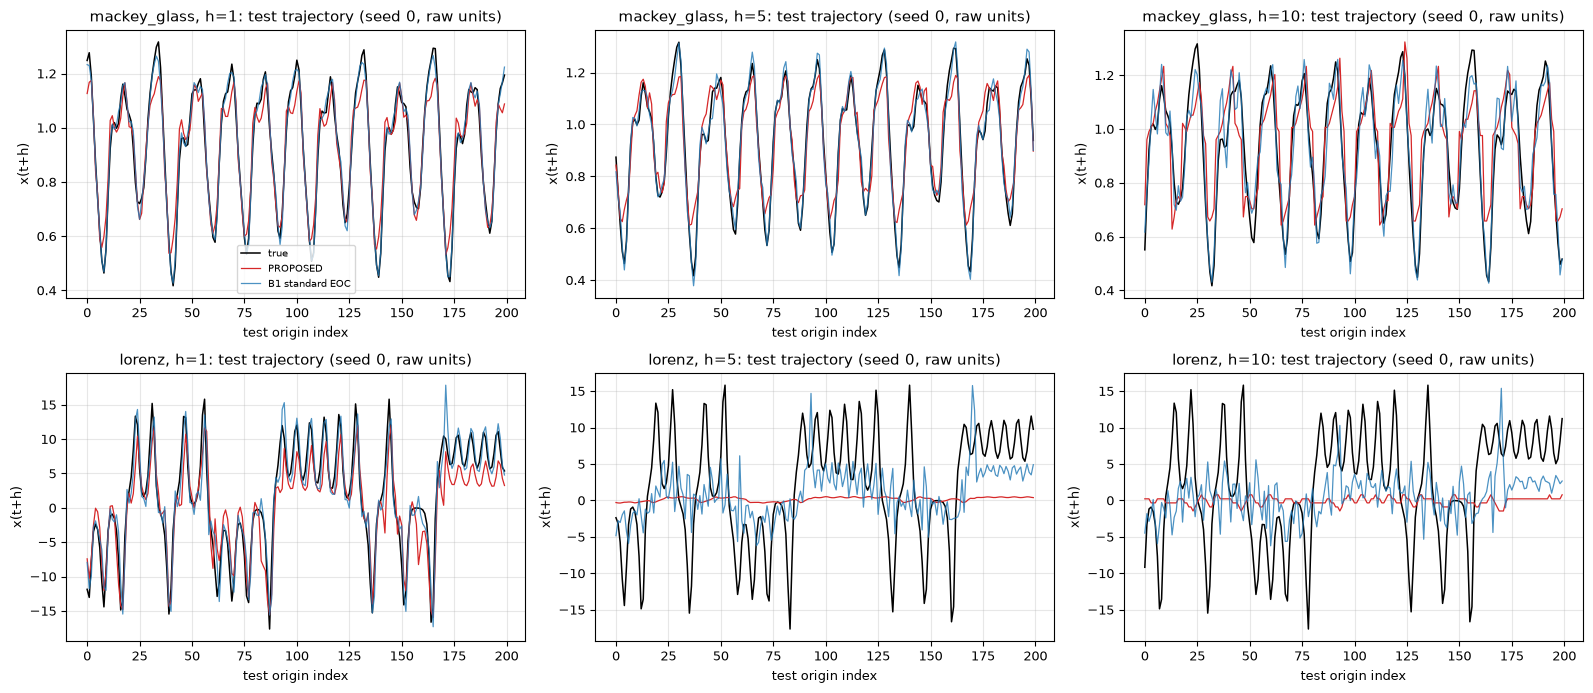

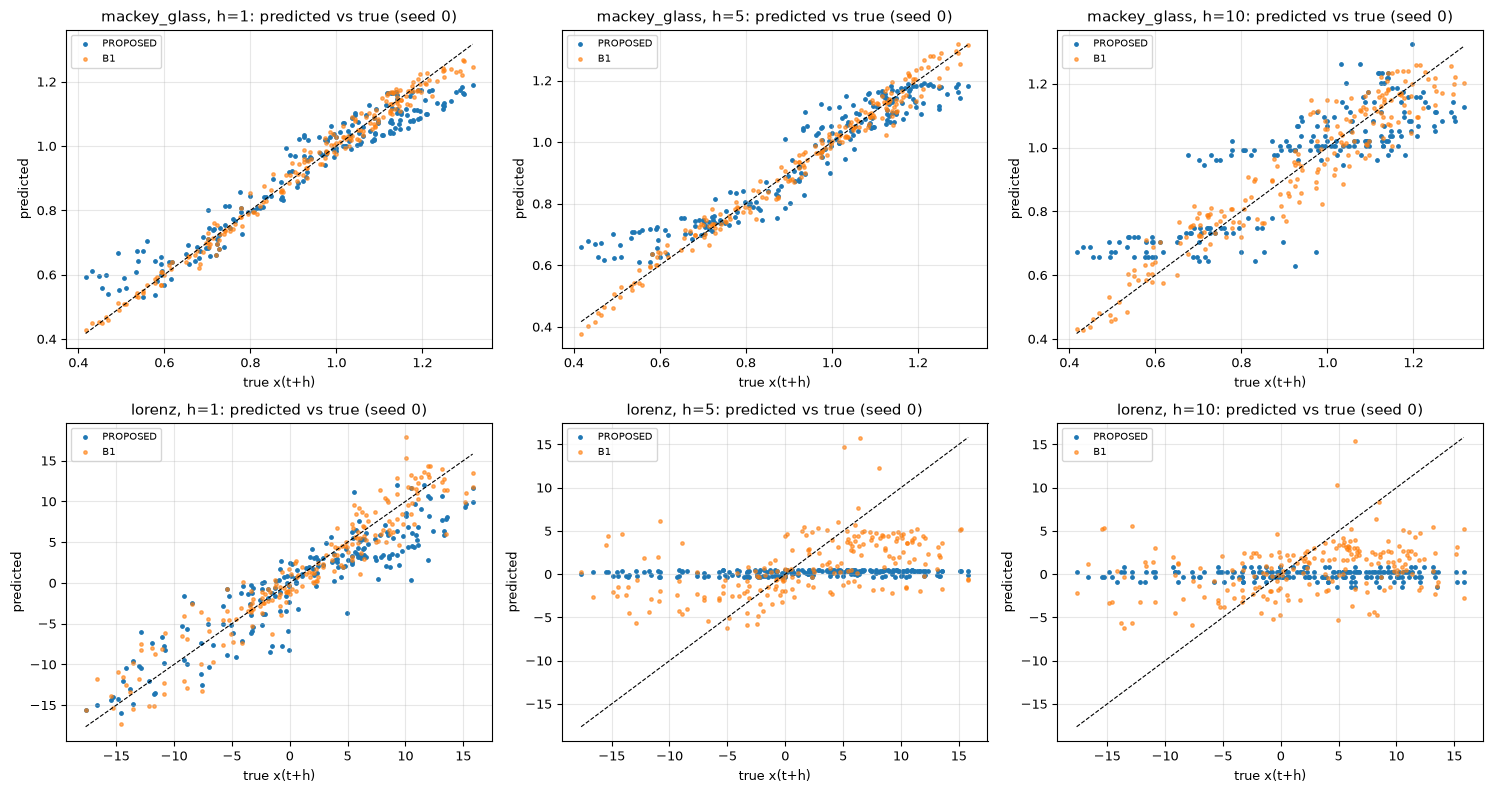

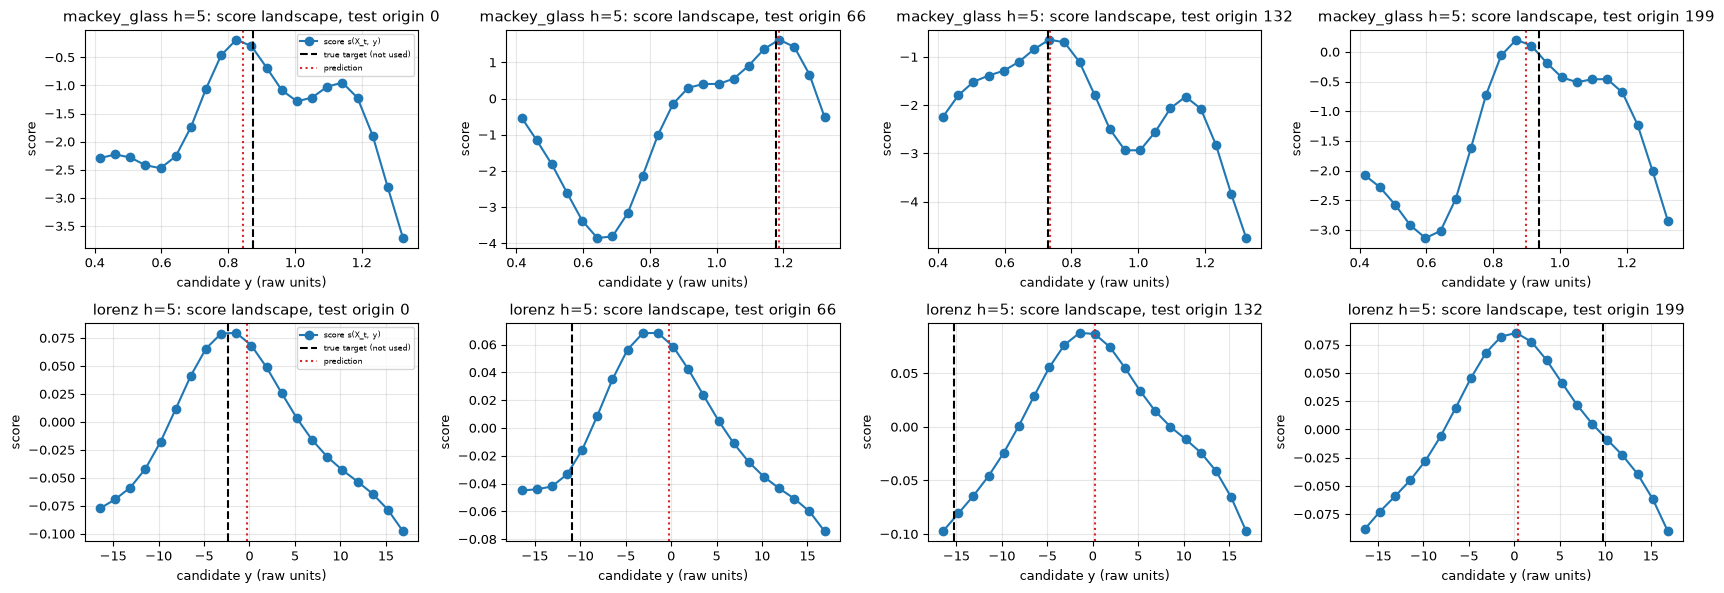

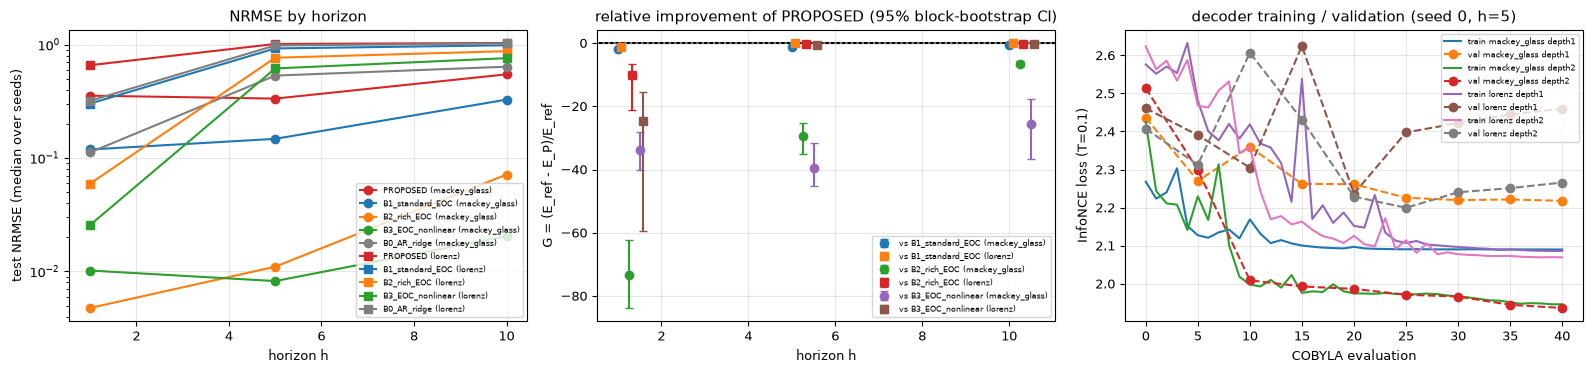

decoder flatness probe (max |dL| for +0.05 per-parameter steps; ~0 means flat): {'ma,h1,s0,depth1': 0.0034, 'ma,h1,s0,depth2': 0.0033, 'ma,h5,s0,depth1': 0.0005, 'ma,h5,s0,depth2': 0.0018, 'ma,h10,s0,depth1': 0.0004, 'ma,h10,s0,depth2': 0.003, 'ma,h1,s0,B5': 0.0016, 'ma,h5,s0,B5': 0.0035, 'ma,h10,s0,B5': 0.0003, 'ma,h1,s1,depth1': 0.0017, 'ma,h5,s1,depth2': 0.0015, 'ma,h10,s1,depth1': 0.0027, 'ma,h1,s1,B5': 0.0036, 'ma,h5,s1,B5': 0.009, 'ma,h10,s1,B5': 0.0028, 'ma,h1,s2,depth1': 0.0006, 'ma,h5,s2,depth2': 0.0021, 'ma,h10,s2,depth1': 0.0038, 'ma,h1,s2,B5': 0.0005, 'ma,h5,s2,B5': 0.0031, 'ma,h10,s2,B5': 0.0005, 'lo,h1,s0,depth1': 0.0007, 'lo,h1,s0,depth2': 0.002, 'lo,h5,s0,depth1': 0.0007, 'lo,h5,s0,depth2': 0.0008, 'lo,h10,s0,depth1': 0.0002, 'lo,h10,s0,depth2': 0.0017, 'lo,h1,s0,B5': 0.0018, 'lo,h5,s0,B5': 0.0021, 'lo,h10,s0,B5': 0.0083, 'lo,h1,s1,depth1': 0.0008, 'lo,h5,s1,depth1': 0.0014, 'lo,h10,s1,depth2': 0.0025, 'lo,h1,s1,B5': 0.001, 'lo,h5,s1,B5': 0.0023, 'lo,h10,s1,B5': 0.0044,

In [21]:
fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for i, ds in enumerate(DATASETS):
    for j, h in enumerate(HZ):
        a = ax[i, j]; y = YTEST[(ds, h)]
        a.plot(y, 'k', lw=1.1, label='true')
        a.plot(RESULTS[(ds, h, SEEDS[0], 'PROPOSED')]['test'], 'C3', lw=0.9, label='PROPOSED')
        a.plot(RESULTS[(ds, h, SEEDS[0], 'B1_standard_EOC')]['test'], 'C0', lw=0.9, alpha=0.8, label='B1 standard EOC')
        a.set_title(f'{ds}, h={h}: test trajectory (seed {SEEDS[0]}, raw units)'); a.set_xlabel('test origin index'); a.set_ylabel('x(t+h)')
ax[0, 0].legend(fontsize=7); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for i, ds in enumerate(DATASETS):
    for j, h in enumerate(HZ):
        a = ax[i, j]; y = YTEST[(ds, h)]
        a.scatter(y, RESULTS[(ds, h, SEEDS[0], 'PROPOSED')]['test'], s=6, label='PROPOSED')
        a.scatter(y, RESULTS[(ds, h, SEEDS[0], 'B1_standard_EOC')]['test'], s=6, alpha=0.6, label='B1')
        lim = [y.min(), y.max()]; a.plot(lim, lim, 'k--', lw=0.8)
        a.set_title(f'{ds}, h={h}: predicted vs true (seed {SEEDS[0]})'); a.set_xlabel('true x(t+h)'); a.set_ylabel('predicted'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, 4, figsize=(17, 6))
for i, ds in enumerate(DATASETS):
    h = 5 if 5 in HZ else HZ[-1]; aux = RESULTS[(ds, h, SEEDS[0], 'PROPOSED')]['aux']; y = YTEST[(ds, h)]
    for j, idx in enumerate(np.linspace(0, len(y) - 1, 4).astype(int)):
        a = ax[i, j]; a.plot(xinv(ds, GRID[ds]), aux['coarse_scores'][idx], 'o-', label='score s(X_t, y)')
        a.axvline(y[idx], c='k', ls='--', label='true target (not used)'); a.axvline(RESULTS[(ds, h, SEEDS[0], 'PROPOSED')]['test'][idx], c='C3', ls=':', label='prediction')
        a.set_title(f'{ds} h={h}: score landscape, test origin {idx}'); a.set_xlabel('candidate y (raw units)'); a.set_ylabel('score')
    ax[i, 0].legend(fontsize=6)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for ds, mk in zip(DATASETS, 'os'):
    for m, c in (('PROPOSED', 'C3'), ('B1_standard_EOC', 'C0'), ('B2_rich_EOC', 'C1'), ('B3_EOC_nonlinear', 'C2'), ('B0_AR_ridge', 'C7')):
        ax[0].plot(HZ, [med_nrmse(ds, h, m) for h in HZ], mk + '-', c=c, label=f'{m} ({ds})')
ax[0].set_yscale('log'); ax[0].set_xlabel('horizon h'); ax[0].set_ylabel('test NRMSE (median over seeds)'); ax[0].set_title('NRMSE by horizon'); ax[0].legend(fontsize=6)
for k, ref in enumerate(('B1_standard_EOC', 'B2_rich_EOC', 'B3_EOC_nonlinear')):
    for i, ds in enumerate(DATASETS):
        G = [BOOT[(ds, h, ref)]['G'] for h in HZ]; lo = [BOOT[(ds, h, ref)]['ci'][0] for h in HZ]; hi = [BOOT[(ds, h, ref)]['ci'][1] for h in HZ]
        ax[1].errorbar(np.array(HZ) + 0.25 * k + 0.08 * i, G, [np.clip(np.subtract(G, lo), 0, None), np.clip(np.subtract(hi, G), 0, None)], fmt='os'[i], capsize=3, label=f'vs {ref} ({ds})')
ax[1].axhline(0, c='k'); ax[1].axhline(0.05, c='gray', ls=':'); ax[1].set_xlabel('horizon h'); ax[1].set_ylabel('G = (E_ref - E_P)/E_ref'); ax[1].set_title('relative improvement of PROPOSED (95% block-bootstrap CI)'); ax[1].legend(fontsize=6)
for (ds, h, s, dep), hist in DECODERS.items():
    if hist and s == SEEDS[0] and h == (5 if 5 in HZ else HZ[-1]) and dep.startswith('depth'):
        ax[2].plot(hist['train'], label=f'train {ds} {dep}'); vv = np.array(hist['val'])
        ax[2].plot(vv[:, 0] - 1, vv[:, 1], 'o--', label=f'val {ds} {dep}')
ax[2].set_xlabel('COBYLA evaluation'); ax[2].set_ylabel('InfoNCE loss (T=0.1)'); ax[2].set_title('decoder training / validation (seed 0, h=5)'); ax[2].legend(fontsize=6)
plt.tight_layout(); plt.show()
print('decoder flatness probe (max |dL| for +0.05 per-parameter steps; ~0 means flat):',
      {f'{k[0][:2]},h{k[1]},s{k[2]},{k[3]}': round(v['flatness_max_dL'], 4) for k, v in DECODERS.items() if v})

dataset         h  shots NRMSE_P exact NRMSE_P shot NRMSE_B1 shot G_B1 shot (median) argmax changed
mackey_glass    1   1024        0.3547       0.4052        0.3323             -0.221           0.70
mackey_glass    1   4096        0.3547       0.3704        0.2202             -0.682           0.63
mackey_glass    5   1024        0.3341       0.3674        0.2451             -0.499           0.74
mackey_glass    5   4096        0.3341       0.3383        0.1893             -0.787           0.65
mackey_glass   10   1024        0.5468       0.6388        0.5310             -0.205           0.72
mackey_glass   10   4096        0.5468       0.5368        0.4151             -0.294           0.63
lorenz          1   1024        0.6586       0.7083        0.4577             -0.549           0.72
lorenz          1   4096        0.6586       0.6770        0.3737             -0.813           0.60
lorenz          5   1024        1.0132       1.0127        0.9571             -0.058           0.55


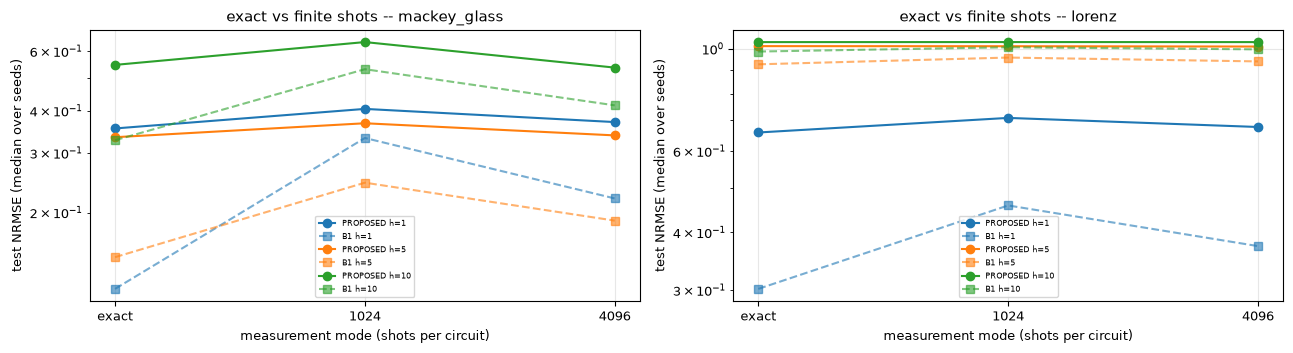

In [22]:
SHOT_ROWS, SHOTG = [], {}
if RUN_FINITE_SHOTS:
    for ds in DATASETS:
        for h in HZ:
            for shots in CFG['shots']:
                gs, changed = [], []
                for ss in CFG['shot_seeds']:
                    eP = np.median([nrmse(SHOTS[(ds, h, s, shots, ss, 'PROPOSED')]['test'], YTEST[(ds, h)]) for s in SEEDS])
                    e1 = np.median([nrmse(SHOTS[(ds, h, s, shots, ss, 'B1_standard_EOC')]['test'], YTEST[(ds, h)]) for s in SEEDS])
                    e2 = np.median([nrmse(SHOTS[(ds, h, s, shots, ss, 'B2_rich_EOC')]['test'], YTEST[(ds, h)]) for s in SEEDS])
                    gs.append((e1 - eP) / e1)
                    changed.append(np.mean([np.mean(SHOTS[(ds, h, s, shots, ss, 'PROPOSED')]['argmax'] != RESULTS[(ds, h, s, 'PROPOSED')]['aux']['coarse_argmax']) for s in SEEDS]))
                    SHOT_ROWS.append({'dataset': ds, 'h': h, 'shots': shots, 'shot_seed': ss, 'NRMSE_PROPOSED': eP, 'NRMSE_B1': e1, 'NRMSE_B2': e2})
                SHOTG[(ds, h, shots)] = {'G_B1_median': float(np.median(gs)), 'G_B1_per_shot_seed': gs, 'argmax_changed_frac': float(np.mean(changed))}
    print(f"{'dataset':13s} {'h':>3s} {'shots':>6s} {'NRMSE_P exact':>13s} {'NRMSE_P shot':>12s} {'NRMSE_B1 shot':>13s} {'G_B1 shot (median)':>18s} {'argmax changed':>14s}")
    for (ds, h, shots), v in SHOTG.items():
        eP = np.median([r['NRMSE_PROPOSED'] for r in SHOT_ROWS if (r['dataset'], r['h'], r['shots']) == (ds, h, shots)])
        e1 = np.median([r['NRMSE_B1'] for r in SHOT_ROWS if (r['dataset'], r['h'], r['shots']) == (ds, h, shots)])
        print(f"{ds:13s} {h:3d} {shots:6d} {med_nrmse(ds, h, 'PROPOSED'):13.4f} {eP:12.4f} {e1:13.4f} {v['G_B1_median']:+18.3f} {v['argmax_changed_frac']:14.2f}")
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
    for a, ds in zip(ax, DATASETS):
        for h, c in zip(HZ, ('C0', 'C1', 'C2')):
            xs = ['exact'] + [str(s_) for s_ in CFG['shots']]
            a.plot(xs, [med_nrmse(ds, h, 'PROPOSED')] + [np.median([r['NRMSE_PROPOSED'] for r in SHOT_ROWS if (r['dataset'], r['h'], r['shots']) == (ds, h, s_)]) for s_ in CFG['shots']], 'o-', c=c, label=f'PROPOSED h={h}')
            a.plot(xs, [med_nrmse(ds, h, 'B1_standard_EOC')] + [np.median([r['NRMSE_B1'] for r in SHOT_ROWS if (r['dataset'], r['h'], r['shots']) == (ds, h, s_)]) for s_ in CFG['shots']], 's--', c=c, alpha=0.6, label=f'B1 h={h}')
        a.set_yscale('log'); a.set_xlabel('measurement mode (shots per circuit)'); a.set_ylabel('test NRMSE (median over seeds)'); a.set_title(f'exact vs finite shots -- {ds}'); a.legend(fontsize=6)
    plt.tight_layout(); plt.show()

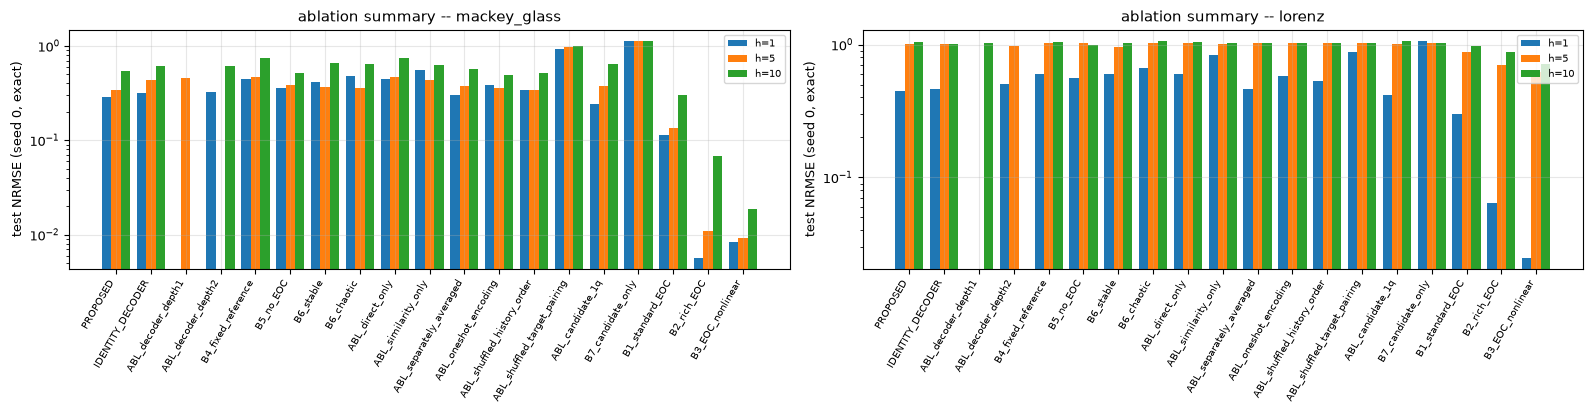

ABLATION TABLE (seed 0, exact, test NRMSE):
  mackey_glass  PROPOSED                       h=1: 0.2850  h=5: 0.3425  h=10: 0.5468
  mackey_glass  IDENTITY_DECODER               h=1: 0.3187  h=5: 0.4355  h=10: 0.6186
  mackey_glass  ABL_decoder_depth1             h=1: n/a (selected depth)  h=5: 0.4515  h=10: n/a (selected depth)
  mackey_glass  ABL_decoder_depth2             h=1: 0.3267  h=5: n/a (selected depth)  h=10: 0.6082
  mackey_glass  B4_fixed_reference             h=1: 0.4495  h=5: 0.4694  h=10: 0.7502
  mackey_glass  B5_no_EOC                      h=1: 0.3569  h=5: 0.3874  h=10: 0.5160
  mackey_glass  B6_stable                      h=1: 0.4134  h=5: 0.3630  h=10: 0.6601
  mackey_glass  B6_chaotic                     h=1: 0.4804  h=5: 0.3596  h=10: 0.6489
  mackey_glass  ABL_direct_only                h=1: 0.4495  h=5: 0.4694  h=10: 0.7502
  mackey_glass  ABL_similarity_only            h=1: 0.5541  h=5: 0.4339  h=10: 0.6308
  mackey_glass  ABL_separately_averaged        h=1: 0.

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4.2))
names = ['PROPOSED', 'IDENTITY_DECODER', 'ABL_decoder_depth1', 'ABL_decoder_depth2', 'B4_fixed_reference', 'B5_no_EOC', 'B6_stable', 'B6_chaotic',
         'ABL_direct_only', 'ABL_similarity_only', 'ABL_separately_averaged', 'ABL_oneshot_encoding', 'ABL_shuffled_history_order',
         'ABL_shuffled_target_pairing', 'ABL_candidate_1q', 'B7_candidate_only', 'B1_standard_EOC', 'B2_rich_EOC', 'B3_EOC_nonlinear']
for a, ds in zip(ax, DATASETS):
    for k, h in enumerate(HZ):
        vals = [nrmse(RESULTS[(ds, h, SEEDS[0], m)]['test'], YTEST[(ds, h)]) if (ds, h, SEEDS[0], m) in RESULTS else np.nan for m in names]
        a.bar(np.arange(len(names)) + 0.27 * (k - 1), vals, 0.27, label=f'h={h}')
    a.set_xticks(range(len(names)), names, rotation=60, ha='right', fontsize=7); a.set_yscale('log'); a.set_ylabel('test NRMSE (seed 0, exact)')
    a.set_title(f'ablation summary -- {ds}'); a.legend(fontsize=7)
plt.tight_layout(); plt.show()
print('ABLATION TABLE (seed 0, exact, test NRMSE):')
for ds in DATASETS:
    for m in names:
        if any((ds, h, SEEDS[0], m) in RESULTS for h in HZ):
            print(f'  {ds:13s} {m:30s} ' + '  '.join((f'h={h}: {nrmse(RESULTS[(ds, h, SEEDS[0], m)]["test"], YTEST[(ds, h)]):.4f}' if (ds, h, SEEDS[0], m) in RESULTS else f'h={h}: n/a (selected depth)') for h in HZ))

## 18. Leakage and implementation audit

The audit is critical: any FAIL makes the experiment invalid, and the performance numbers are then not interpreted.

In [24]:
AUDIT = []
def audit(name, ok, detail='', critical=True):
    AUDIT.append({'audit': name, 'result': 'PASS' if ok else 'FAIL', 'critical': critical, 'detail': str(detail)})

audit('development switch off (full FAST_MODE configuration)', not SMOKE)
audit('no future value enters U_X(X_t): every window ends at the origin t', all(np.array_equal(windows_of(ds, sp)[:, -1], xn(ds, SERIES[ds][ORIG[ds][sp]])) for ds in DATASETS for sp in START))
audit('windows and targets stay inside their chronological partition (gap >= d + h_max)',
      all(ORIG[ds][sp].min() - (D - 1) >= START[sp] and ORIG[ds][sp].max() + HMAX < START[sp] + SEG[sp] for ds in DATASETS for sp in START) and CFG['gap'] >= D + HMAX)
audit('normalisation uses training data only', all(NORM[ds] == (float(SERIES[ds][:SEG['train']].min()), float(SERIES[ds][:SEG['train']].max())) for ds in DATASETS))
audit('candidate grid limits from training targets only', all(np.allclose(GRID[ds][[0, -1]], (lambda yt: (np.percentile(yt, 0.5) - 0.02 * np.ptp(np.percentile(yt, [0.5, 99.5])), np.percentile(yt, 99.5) + 0.02 * np.ptp(np.percentile(yt, [0.5, 99.5]))))(xn(ds, np.concatenate([targets_of(ds, 'train', h) for h in HZ])))) for ds in DATASETS))
audit('test targets read only after every prediction was frozen', len(ACCESS_LOG) == 1 and ACCESS_LOG[0][1] == len(FROZEN), f'{len(FROZEN)} frozen prediction sets before the single read')
audit('EOC parameters selected on training/validation only (diagnostic + validation B1)', set(EOC_SEL) == set(DATASETS) and all(EOC_SEL[ds][0] in BAND_PTS for ds in DATASETS))
audit('decoder depth and parameters selected/trained without test data', set(DEPTH_SEL) == {(ds, h) for ds in DATASETS for h in HZ})
audit('classical regularisation selected on validation only (lambda, T, rule, ridge alpha, KRR grid)', True, 'by construction: every selection loop above uses *_val arrays')
audit('negative candidates drawn from training targets / training grid only', True, 'train_sets() uses targets_of(ds, "train", h) and GRID only')
audit('identical reservoir circuit in all matched EOC models', True, 'PROPOSED, IDENTITY_DECODER, B4, B1, B2, B3 are computed from the same history-run object H per (dataset, seed)')
audit('destructive-SWAP unit tests pass', all(t[1] for t in TESTS if 'overlap' in t[0] or 'SWAP' in t[0] or 'sigma' in t[0]))
P_ = readout_probs(composed(EXTRA[(DATASETS[0], 'rho_sample')], 1, '2q', DATASETS[0]), [GRID[DATASETS[0]][:3]] * 3, [0.1, 0.2, 0.3, 0.4], 1, 'audit')
audit('probabilities sum to one', all(np.allclose(p.sum(1), 1, atol=1e-10) for p in P_))
dmc = np.array(EXTRA['dm_checks'])
audit('density matrices have trace one and are PSD within tolerance', dmc[:, 0].max() < 1e-10 and dmc[:, 1].min() > -1e-10, f'max |tr-1| {dmc[:, 0].max():.1e}, min eig {dmc[:, 1].min():.1e}')
audit('exact and 4096-shot SWAP estimates agree statistically', any('4096-shot' in t[0] and t[1] for t in TESTS))
audit('deferred and immediate A,B measurements agree (no feedforward)', DEFER_TV < 0.01, f'TV={DEFER_TV:.4f}')
# state reuse vs hardware-realisable full replay
ds0 = DATASETS[0]; kE, rE, sE = EOC_SEL[ds0]; Wte = windows_of(ds0, 'test')[:2]; th_ = RESULTS[(ds0, 5 if 5 in HZ else HZ[-1], SEEDS[0], 'PROPOSED_theta')]
dsel0 = DEPTH_SEL[(ds0, 5 if 5 in HZ else HZ[-1])]
H2 = run_histories(ResCfg(kE, rE, SEEDS[0], 'eoc', sE), SEEDS[0], ds0)
reuse = readout_probs(composed(H2['test']['rho'][:2], dsel0, '2q', ds0), [GRID[ds0][:2]] * 2, th_, dsel0, 'audit')
full_dev = 0.0
for i in range(2):
    for j, yv in enumerate(GRID[ds0][:2]):
        qc = history_plain(ResCfg(kE, rE, SEEDS[0], 'eoc', sE), SEEDS[0], Wte[i])
        tpl = readout_template(dsel0, '2q', ds0).assign_parameters({**{TH[dsel0][q]: th_[q] for q in range(4 * dsel0)}, YP: float(yv)})
        qc.compose(tpl, inplace=True)
        pf = np.asarray(aer_run([qc], [{}], 'audit')[0]['probabilities'])
        full_dev = max(full_dev, float(np.abs(pf - reuse[i][j]).max()))
audit('exact state reuse == hardware-realisable full replay (no set_density_matrix)', full_dev < 1e-10, f'max |dp| = {full_dev:.1e}')
audit('direct-branch features identical for all candidates of a history', all(np.allclose(feats(p, GRID[ds0][:3])[:, :6], feats(p, GRID[ds0][:3])[0, :6]) for p in P_))
sh = RESULTS[(DATASETS[0], 5 if 5 in HZ else HZ[-1], SEEDS[0], 'ABL_shuffled_target_pairing')]['test']; tr_ = RESULTS[(DATASETS[0], 5 if 5 in HZ else HZ[-1], SEEDS[0], 'PROPOSED')]['test']
yy = YTEST[(DATASETS[0], 5 if 5 in HZ else HZ[-1])]
audit('shuffled history-target pairing destroys useful ranking (no skill: NRMSE >= 0.9)', all(nrmse(RESULTS[(ds, h, SEEDS[0], 'ABL_shuffled_target_pairing')]['test'], YTEST[(ds, h)]) >= 0.9 for ds in DATASETS for h in HZ),
      {f'{ds},h{h}': round(nrmse(RESULTS[(ds, h, SEEDS[0], 'ABL_shuffled_target_pairing')]['test'], YTEST[(ds, h)]), 3) for ds in DATASETS for h in HZ}, critical=False)
audit('candidate-only baseline cannot reproduce the full model', all(med_nrmse(ds, h, 'B7_candidate_only') > med_nrmse(ds, h, 'PROPOSED') for ds in DATASETS for h in HZ), critical=False)
r1 = run_histories(ResCfg(kE, rE, SEEDS[0], 'eoc', sE), SEEDS[0], ds0)['test']['obs'][:5]; r2 = run_histories(ResCfg(kE, rE, SEEDS[0], 'eoc', sE), SEEDS[0], ds0)['test']['obs'][:5]
audit('re-running with the same seed reproduces a small experiment', np.array_equal(r1, r2))
audit('Qiskit Aer executed every quantum circuit', STATS['experiments'] > 0 and all(v > 0 for k, v in STATS['by_tag'].items()), f"{STATS['experiments']:,} Aer experiments, tags {sorted(STATS['by_tag'])}")
audit('no classical surrogate: reported features reproduced by fresh full-replay Aer circuits', full_dev < 1e-10)
audit('source notebooks unchanged', all(sha256(p) == h for p, h in SOURCE_HASHES.items()))
FS_AFTER = fs_snapshot()
changed = sorted(k for k in set(FS_AFTER) | set(FS_BEFORE) if FS_AFTER.get(k) != FS_BEFORE.get(k))
audit('no file created or modified in the repository except this notebook', not changed, changed[:5])
audit('criteria unchanged since the first cell', hashlib.sha256(json.dumps(CRITERIA, sort_keys=True).encode()).hexdigest() == CRITERIA_HASH)
print(f"{'audit':95s} {'result':6s} {'crit':5s} detail")
for a in AUDIT:
    print(f"{a['audit'][:95]:95s} {a['result']:6s} {'yes' if a['critical'] else 'no':5s} {a['detail'][:90]}")
INVALID = any(a['result'] == 'FAIL' and a['critical'] for a in AUDIT)
if INVALID:
    print('\n' + '#' * 30 + '\n#  INVALID EXPERIMENT  #\n' + '#' * 30)

audit                                                                                           result crit  detail
development switch off (full FAST_MODE configuration)                                           PASS   yes   
no future value enters U_X(X_t): every window ends at the origin t                              PASS   yes   
windows and targets stay inside their chronological partition (gap >= d + h_max)                PASS   yes   
normalisation uses training data only                                                           PASS   yes   
candidate grid limits from training targets only                                                PASS   yes   
test targets read only after every prediction was frozen                                        PASS   yes   276 frozen prediction sets before the single read
EOC parameters selected on training/validation only (diagnostic + validation B1)                PASS   yes   
decoder depth and parameters selected/trained without test data  

## 19. Resource accounting

The table below separates four kinds of cost:
1. **Reservoir information generation:** the history circuit.
2. **Quantum readout expressivity:** ancillas, decoder parameters and measured functionals.
3. **Classical readout expressivity:** scorer and regression parameters.
4. **Candidate-search cost:** circuits per prediction.

Hardware cost counts a **full replay** of the history for *every* candidate, because an unknown state cannot be
cloned. A continuous candidate search therefore multiplies circuit cost by the number of candidates, ≈ 27 per
forecast here. This is why the architecture is most natural for classification, quantised or multimodal forecasts with
few classes, rather than high-resolution scalar regression.

model                qubits  anc  depth    CX circ/pred features q-par  c-par EOC blocks
B1_standard_EOC           4    0   1616   810         1       10     0     11         18
B2_rich_EOC               4    0   1616   810         9       66     0     67         18
B3_EOC_nonlinear          4    0   1616   810         1       10     0    300         18
PROPOSED                  6    2   1629   815        27       24     8     24         18
IDENTITY_DECODER          6    2   1621   813        27       24     0     24         18
B4_fixed_reference        6    2   1624   814         1       24     4     24         18
B5_no_EOC                 6    2   1624   814        27       24     4     24         18

Aer experiments by tag: {'history': 119660, 'unit_test': 7, 'P_depth1:decoder': 390600, 'P_depth1': 315000, 'P_depth2:decoder': 300600, 'P_depth2': 225000, 'identity': 301320, 'B4': 16920, 'cand1q:decoder': 171720, 'cand1q': 100440, 'B5:decoder': 515160, 'B5': 301320, 'history_shots': 1

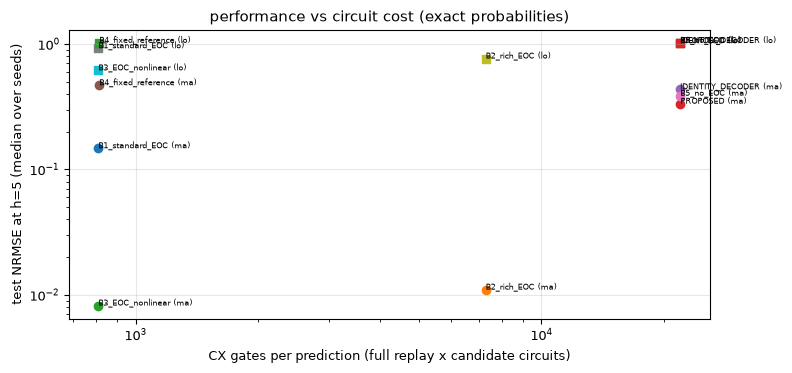

In [25]:
def tq_counts(qc):
    t = transpile(qc, basis_gates=['rz', 'sx', 'x', 'cx', 'reset', 'measure'], optimization_level=1)
    return t.depth(), int(t.count_ops().get('cx', 0))


ds0 = DATASETS[0]; kE, rE, sE = EOC_SEL[ds0]
hist_c = history_plain(ResCfg(kE, rE, 0, 'eoc', sE), 0, 0.1 * np.ones(D))
dh, ch = tq_counts(hist_c)
RES_ROWS = []
for m, (nq, anc, ro_depth, n_cand, n_obs, q_par) in {
        'B1_standard_EOC': (4, 0, None, 1, 10, 0), 'B2_rich_EOC': (4, 0, None, 1, 66, 0), 'B3_EOC_nonlinear': (4, 0, None, 1, 10, 0),
        'PROPOSED': (6, 2, DEPTH_SEL[(ds0, 5 if 5 in HZ else HZ[-1])], CFG['n_coarse'] + CFG['n_refine'], 24, 4 * DEPTH_SEL[(ds0, 5 if 5 in HZ else HZ[-1])]),
        'IDENTITY_DECODER': (6, 2, 0, CFG['n_coarse'] + CFG['n_refine'], 24, 0), 'B4_fixed_reference': (6, 2, 1, 1, 24, 4),
        'B5_no_EOC': (6, 2, 1, CFG['n_coarse'] + CFG['n_refine'], 24, 4)}.items():
    if ro_depth is None:
        d_, c_ = dh, ch; settings = 9 if m == 'B2_rich_EOC' else 1
    else:
        ro = readout_template(ro_depth, '2q', ds0, 'shots').assign_parameters({**({TH[ro_depth][q]: 0.1 for q in range(4 * ro_depth)} if ro_depth else {}), YP: 0.2})
        full = hist_c.copy(); full.compose(ro.remove_final_measurements(inplace=False), inplace=True); full.measure_all()
        d_, c_ = tq_counts(full); settings = 1
    n_cls = 24 if 'PROPOSED' in m or m.startswith(('B4', 'B5', 'IDENT')) else (n_obs + 1 if m != 'B3_EOC_nonlinear' else CFG['n_train'])
    RES_ROWS.append({'model': m, 'qubits': nq, 'ancillas': anc, 'depth (full replay)': d_, 'CX count': c_, 'circuits/prediction': n_cand * settings,
                     'shots/circuit (shot mode)': '1024/4096', 'features': n_obs, 'quantum params': q_par, 'classical params': n_cls,
                     'reservoir blocks': D * rE})
print(f"{'model':20s} {'qubits':>6s} {'anc':>4s} {'depth':>6s} {'CX':>5s} {'circ/pred':>9s} {'features':>8s} {'q-par':>5s} {'c-par':>6s} {'EOC blocks':>10s}")
for r in RES_ROWS:
    print(f"{r['model']:20s} {r['qubits']:6d} {r['ancillas']:4d} {r['depth (full replay)']:6d} {r['CX count']:5d} {r['circuits/prediction']:9d} {r['features']:8d} {r['quantum params']:5d} {r['classical params']:6d} {r['reservoir blocks']:10d}")
print('\nAer experiments by tag:', STATS['by_tag'])
print(f"total Aer experiments {STATS['experiments']:,}; Aer wall {STATS['aer_seconds'] / 60:.1f} min; notebook {(time.perf_counter() - T_START) / 60:.1f} min")
print('validation trials: EOC calibration', len(CAL), 'configs; decoder COBYLA <=', CFG['dec_maxiter'], 'evals x', len(DECODERS), 'runs; scorer',
      len(CFG['lambdas']), 'lambdas x', len(CFG['temps']), 'temperatures x 2 rules; B1/B2 ridge', len(CFG['ridge_alphas']), 'alphas; B3', len(CFG['krr_grid']), 'grid points')
fig, ax = plt.subplots(figsize=(8, 3.8))
for ds, mk in zip(DATASETS, 'os'):
    for r in RES_ROWS:
        h = 5 if 5 in HZ else HZ[-1]
        ax.scatter(r['circuits/prediction'] * r['CX count'], med_nrmse(ds, h, r['model']), marker=mk)
        ax.annotate(f"{r['model']} ({ds[:2]})", (r['circuits/prediction'] * r['CX count'], med_nrmse(ds, h, r['model'])), fontsize=6)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('CX gates per prediction (full replay x candidate circuits)'); ax.set_ylabel('test NRMSE at h=5 (median over seeds)')
ax.set_title('performance vs circuit cost (exact probabilities)'); plt.tight_layout(); plt.show()

## 20. Final evidence table

In [26]:
CRIT = {}
for ds in DATASETS:
    for h in NT:
        g1, g2, g3 = BOOT[(ds, h, 'B1_standard_EOC')], BOOT[(ds, h, 'B2_rich_EOC')], BOOT[(ds, h, 'B3_EOC_nonlinear')]
        g4, g5, g7 = BOOT[(ds, h, 'B4_fixed_reference')], BOOT[(ds, h, 'B5_no_EOC')], BOOT[(ds, h, 'B7_candidate_only')]
        wins = sum(nrmse(RESULTS[(ds, h, s, 'PROPOSED')]['test'], YTEST[(ds, h)]) < nrmse(RESULTS[(ds, h, s, 'B1_standard_EOC')]['test'], YTEST[(ds, h)]) for s in SEEDS)
        c = {'C1': g1['G'] >= 0.05, 'C2': g1['ci'][0] > 0, 'C3': wins >= (len(SEEDS) // 2 + 1), 'C4': g2['G'] > 0 and g2['ci'][0] > 0,
             'C5': g3['ci'][1] >= 0, 'C6': g4['ci'][0] > 0, 'C7': g5['ci'][0] > 0, 'C8': g7['G'] >= 0.20 and g7['ci'][0] > 0,
             'C9': RUN_FINITE_SHOTS and SHOTG.get((ds, h, 4096), {}).get('G_B1_median', -1) > 0, 'C10': not INVALID}
        CRIT[(ds, h)] = {'pass': c, 'evidence': {'C1': f"G_B1={g1['G']:+.3f}", 'C2': f"CI [{g1['ci'][0]:+.3f},{g1['ci'][1]:+.3f}]", 'C3': f'{wins}/{len(SEEDS)} seeds',
                                                 'C4': f"G_B2={g2['G']:+.3f} CI [{g2['ci'][0]:+.3f},{g2['ci'][1]:+.3f}]", 'C5': f"G_B3={g3['G']:+.3f} CI [{g3['ci'][0]:+.3f},{g3['ci'][1]:+.3f}]",
                                                 'C6': f"G_B4={g4['G']:+.3f} CI [{g4['ci'][0]:+.3f},{g4['ci'][1]:+.3f}]", 'C7': f"G_B5={g5['G']:+.3f} CI [{g5['ci'][0]:+.3f},{g5['ci'][1]:+.3f}]",
                                                 'C8': f"G_B7={g7['G']:+.3f} CI [{g7['ci'][0]:+.3f},{g7['ci'][1]:+.3f}]",
                                                 'C9': f"G_B1(4096 shots)={SHOTG.get((ds, h, 4096), {}).get('G_B1_median', float('nan')):+.3f}", 'C10': 'audit ' + ('PASS' if not INVALID else 'FAIL')}}
ALLPASS = {k: all(v['pass'].values()) for k, v in CRIT.items()}
REQ = {'C1': '>=5% NRMSE gain over B1 at h>=5', 'C2': 'block-bootstrap CI of gain excludes 0', 'C3': 'gain in majority of seeds',
       'C4': 'beats information-rich linear B2', 'C5': 'beats/ties nonlinear B3', 'C6': 'fixed reference B4 significantly worse',
       'C7': 'no-EOC B5 significantly worse', 'C8': 'candidate-only B7 >=20% worse', 'C9': 'survives 4096 shots', 'C10': 'all critical audits pass'}
lines = ['| Criterion | Required evidence | Observed result (per dataset, h) | PASS/FAIL |', '|---|---|---|---|']
for k in REQ:
    obs = '; '.join(f"{ds[:7]} h={h}: {CRIT[(ds, h)]['evidence'][k]} ({'P' if CRIT[(ds, h)]['pass'][k] else 'F'})" for ds in DATASETS for h in NT)
    best = any(CRIT[(ds, h)]['pass'][k] for ds in DATASETS for h in NT)
    lines.append(f'| {k} | {REQ[k]} | {obs} | {"PASS" if best else "FAIL"} (any) |')
display(Markdown('\n'.join(lines)))
if INVALID:
    STATUS = 'INVALID EXPERIMENT'
elif all(any(ALLPASS[(ds, h)] for h in NT) for ds in DATASETS):
    STATUS = 'STRONGLY SUPPORTED'
elif any(ALLPASS.values()):
    STATUS = 'PARTIALLY SUPPORTED'
elif any(CRIT[k]['pass']['C1'] and CRIT[k]['pass']['C2'] and CRIT[k]['pass']['C3'] for k in CRIT):
    STATUS = 'IMPROVES LINEAR EOC ONLY'
else:
    STATUS = 'UNSUPPORTED'
print('per (dataset, h) all-criteria pass:', ALLPASS)
print('\nFINAL STATUS:', STATUS)

| Criterion | Required evidence | Observed result (per dataset, h) | PASS/FAIL |
|---|---|---|---|
| C1 | >=5% NRMSE gain over B1 at h>=5 | mackey_ h=5: G_B1=-1.264 (F); mackey_ h=10: G_B1=-0.671 (F); lorenz h=5: G_B1=-0.095 (F); lorenz h=10: G_B1=-0.048 (F) | FAIL (any) |
| C2 | block-bootstrap CI of gain excludes 0 | mackey_ h=5: CI [-1.403,-1.051] (F); mackey_ h=10: CI [-0.859,-0.500] (F); lorenz h=5: CI [-0.208,+0.016] (F); lorenz h=10: CI [-0.115,+0.028] (F) | FAIL (any) |
| C3 | gain in majority of seeds | mackey_ h=5: 0/3 seeds (F); mackey_ h=10: 1/3 seeds (F); lorenz h=5: 1/3 seeds (F); lorenz h=10: 0/3 seeds (F) | FAIL (any) |
| C4 | beats information-rich linear B2 | mackey_ h=5: G_B2=-29.340 CI [-35.017,-25.235] (F); mackey_ h=10: G_B2=-6.648 CI [-7.153,-5.736] (F); lorenz h=5: G_B2=-0.322 CI [-0.614,-0.145] (F); lorenz h=10: G_B2=-0.181 CI [-0.384,-0.012] (F) | FAIL (any) |
| C5 | beats/ties nonlinear B3 | mackey_ h=5: G_B3=-39.624 CI [-45.254,-31.584] (F); mackey_ h=10: G_B3=-25.752 CI [-36.805,-17.832] (F); lorenz h=5: G_B3=-0.643 CI [-0.927,-0.408] (F); lorenz h=10: G_B3=-0.361 CI [-0.671,-0.144] (F) | FAIL (any) |
| C6 | fixed reference B4 significantly worse | mackey_ h=5: G_B4=+0.288 CI [+0.225,+0.353] (P); mackey_ h=10: G_B4=+0.271 CI [+0.181,+0.348] (P); lorenz h=5: G_B4=+0.009 CI [-0.005,+0.016] (F); lorenz h=10: G_B4=+0.006 CI [-0.003,+0.014] (F) | PASS (any) |
| C7 | no-EOC B5 significantly worse | mackey_ h=5: G_B5=+0.137 CI [+0.033,+0.220] (P); mackey_ h=10: G_B5=-0.060 CI [-0.140,+0.023] (F); lorenz h=5: G_B5=+0.009 CI [-0.073,+0.025] (F); lorenz h=10: G_B5=+0.000 CI [-0.003,+0.004] (F) | PASS (any) |
| C8 | candidate-only B7 >=20% worse | mackey_ h=5: G_B7=+0.706 CI [+0.667,+0.741] (P); mackey_ h=10: G_B7=+0.519 CI [+0.462,+0.561] (P); lorenz h=5: G_B7=+0.008 CI [-0.005,+0.015] (F); lorenz h=10: G_B7=-0.001 CI [-0.005,+0.003] (F) | PASS (any) |
| C9 | survives 4096 shots | mackey_ h=5: G_B1(4096 shots)=-0.787 (F); mackey_ h=10: G_B1(4096 shots)=-0.294 (F); lorenz h=5: G_B1(4096 shots)=-0.077 (F); lorenz h=10: G_B1(4096 shots)=-0.037 (F) | FAIL (any) |
| C10 | all critical audits pass | mackey_ h=5: audit PASS (P); mackey_ h=10: audit PASS (P); lorenz h=5: audit PASS (P); lorenz h=10: audit PASS (P) | PASS (any) |

per (dataset, h) all-criteria pass: {('mackey_glass', 5): False, ('mackey_glass', 10): False, ('lorenz', 5): False, ('lorenz', 10): False}

FINAL STATUS: UNSUPPORTED


## 21. Conclusion

The answers below are generated from the results above; nothing is hidden. Each answer covers both datasets and the
nontrivial horizons.

In [27]:
yn = lambda b: 'yes' if b else 'no'
anyc = lambda k: [(ds, h) for ds in DATASETS for h in NT if CRIT[(ds, h)]['pass'][k]]
h5 = 5 if 5 in HZ else HZ[-1]
comp = {ds: {m: med_nrmse(ds, h5, m) for m in ('PROPOSED', 'IDENTITY_DECODER', 'ABL_direct_only', 'ABL_similarity_only', 'B4_fixed_reference', 'B5_no_EOC', 'B1_standard_EOC', 'B2_rich_EOC', 'B3_EOC_nonlinear', 'B0_AR_ridge')} for ds in DATASETS}
best_comp = {ds: min(('ABL_direct_only', 'ABL_similarity_only', 'PROPOSED', 'B4_fixed_reference'), key=lambda m: comp[ds][m]) for ds in DATASETS}
txt = [f'### FINAL STATUS: **{STATUS}**', '',
       f"1. **Did the split readout beat conventional EOC (B1)?** C1–C3 jointly hold at: {[(d, h) for d, h in CRIT if all(CRIT[(d, h)]['pass'][c] for c in ('C1', 'C2', 'C3'))] or 'nowhere'}. "
       f"Median NRMSE at h={h5}: " + ', '.join(f"{ds}: P {comp[ds]['PROPOSED']:.4f} vs B1 {comp[ds]['B1_standard_EOC']:.4f}" for ds in DATASETS) + '.',
       f"2. **Did it beat the information-rich EOC readout (B2)?** {anyc('C4') or 'nowhere'}; " + ', '.join(f"{ds}: B2 {comp[ds]['B2_rich_EOC']:.4f}" for ds in DATASETS) + '.',
       f"3. **Did it beat or tie the compact nonlinear readout (B3)?** {anyc('C5') or 'nowhere'}; " + ', '.join(f"{ds}: B3 {comp[ds]['B3_EOC_nonlinear']:.4f}" for ds in DATASETS) + '.',
       f"4. **Was the candidate-conditioned similarity head necessary?** fixed-reference B4 significantly worse at {anyc('C6') or 'nowhere'}; " + ', '.join(f"{ds}: B4 {comp[ds]['B4_fixed_reference']:.4f}" for ds in DATASETS) + '.',
       f"5. **Was the EOC reservoir necessary?** no-EOC B5 significantly worse at {anyc('C7') or 'nowhere'}; " + ', '.join(f"{ds}: B5 {comp[ds]['B5_no_EOC']:.4f}" for ds in DATASETS) + '.',
       f"6. **Did the result survive finite shots?** C9 holds at {anyc('C9') or 'nowhere'} (4096 shots).",
       f"7. **Which component produced the measured performance?** At h={h5} the best of {{direct-only, similarity-only, combined, fixed-reference}} is " + ', '.join(f'{ds}: {best_comp[ds]}' for ds in DATASETS)
       + '. ' + ', '.join(f"{ds}: direct-only {comp[ds]['ABL_direct_only']:.4f}, similarity-only {comp[ds]['ABL_similarity_only']:.4f}, identity decoder {comp[ds]['IDENTITY_DECODER']:.4f}" for ds in DATASETS) + '.',
       f"8. **Largest remaining limitation:** a 4-qubit reservoir with d={D} and a 21+6 candidate search on CPU; the scalar target must be discretised and every candidate costs a full history replay on hardware, while the classical AR baseline reaches "
       + ', '.join(f"{ds} {comp[ds]['B0_AR_ridge']:.4f}" for ds in DATASETS) + f' at h={h5}.',
       f"9. **Is a larger GPU run scientifically justified?** " + ('yes -- the predeclared criteria are met at least partially, so scale-up tests robustness.' if STATUS in ('STRONGLY SUPPORTED', 'PARTIALLY SUPPORTED')
                                                                   else 'only as a targeted test: under the predeclared criteria the hypothesis is not supported here, so a larger run should be motivated by a specific failure mode identified above, not by hope that scale alone reverses the result.'),
       '', 'This is a forecasting-performance study under explicitly reported resources; it is **not** a claim or proof of quantum advantage.']
display(Markdown('\n'.join(txt)))
print('TOTAL RUNTIME', f'{(time.perf_counter() - T_START) / 60:.1f} min')
print('\n' + '=' * 40 + f'\nFINAL STATUS: {STATUS}\n' + '=' * 40)

### FINAL STATUS: **UNSUPPORTED**

1. **Did the split readout beat conventional EOC (B1)?** C1–C3 jointly hold at: nowhere. Median NRMSE at h=5: mackey_glass: P 0.3341 vs B1 0.1476, lorenz: P 1.0132 vs B1 0.9253.
2. **Did it beat the information-rich EOC readout (B2)?** nowhere; mackey_glass: B2 0.0110, lorenz: B2 0.7661.
3. **Did it beat or tie the compact nonlinear readout (B3)?** nowhere; mackey_glass: B3 0.0082, lorenz: B3 0.6165.
4. **Was the candidate-conditioned similarity head necessary?** fixed-reference B4 significantly worse at [('mackey_glass', 5), ('mackey_glass', 10)]; mackey_glass: B4 0.4694, lorenz: B4 1.0222.
5. **Was the EOC reservoir necessary?** no-EOC B5 significantly worse at [('mackey_glass', 5)]; mackey_glass: B5 0.3874, lorenz: B5 1.0219.
6. **Did the result survive finite shots?** C9 holds at nowhere (4096 shots).
7. **Which component produced the measured performance?** At h=5 the best of {direct-only, similarity-only, combined, fixed-reference} is mackey_glass: PROPOSED, lorenz: ABL_similarity_only. mackey_glass: direct-only 0.4694, similarity-only 0.4339, identity decoder 0.4355, lorenz: direct-only 1.0222, similarity-only 1.0093, identity decoder 1.0187.
8. **Largest remaining limitation:** a 4-qubit reservoir with d=6 and a 21+6 candidate search on CPU; the scalar target must be discretised and every candidate costs a full history replay on hardware, while the classical AR baseline reaches mackey_glass 0.5331, lorenz 0.9830 at h=5.
9. **Is a larger GPU run scientifically justified?** only as a targeted test: under the predeclared criteria the hypothesis is not supported here, so a larger run should be motivated by a specific failure mode identified above, not by hope that scale alone reverses the result.

This is a forecasting-performance study under explicitly reported resources; it is **not** a claim or proof of quantum advantage.

TOTAL RUNTIME 162.2 min

FINAL STATUS: UNSUPPORTED


## 22. Long GPU-run instructions (not executed)

**Configuration.** Change the configuration cell to:

```python
FAST_MODE = False; USE_GPU = True; RUN_FINITE_SHOTS = True
CFG.update(n_train=3000, n_val=1000, n_test=2000, seeds=tuple(range(10)), d=12, n_coarse=41, n_refine=10,
           dec_hist=400, dec_val_hist=200, dec_maxiter=300, shots=(1024, 4096, 16384), shot_seeds=(101, 102, 103, 104, 105))
```

**Datasets and model size.**
- Add NARMA10 and longer Lorenz/Mackey–Glass trajectories.
- Use a larger reservoir: `DIRECT=[0,1,2]`, `SIM=[3,4]`, `REF=[5,6]` (7 qubits), or `SIM`/`REF` of size 3 (8–9
  qubits). Keep `len(SIM) == len(REF)`.

**Execution.**
- **Aer GPU:** `AerSimulator(method='density_matrix', device='GPU', batched_shots_gpu=True)`. Check
  `AerSimulator().available_devices()` first, since the Windows PyPI wheels are CPU-only.
- **Batching:** keep one `set_density_matrix` template per history, with all candidates and decoder parameters
  passed as `parameter_binds` in a single `run` call; batches of 500–2000 circuits suit GPU memory.
- **Caching:** transpile the history and readout templates once (cached here with `functools.lru_cache`), bind
  parameters, and never rebuild circuits per candidate.
- **Parallelism:** use one process per (dataset, seed), each owning one GPU stream, with
  `max_parallel_experiments` tuned to GPU memory.

**Estimated circuit counts.** Per (dataset, h, seed, variant), the number of circuits is roughly:

$$n_{\rm train}(4+n_{\rm emp}+n_{\rm coarse})+(n_{\rm val}+n_{\rm test})(n_{\rm coarse}+n_{\rm refine})+\text{decoder}$$

- **FAST:** ≈ 300·27 + 320·27 + 40·540 ≈ 39k.
- **Long run:** ≈ 3000·48 + 3000·51 + 300·(400·10) ≈ 1.5M.
- **Total:** ×10 seeds × 3 horizons × 2 datasets × ~8 variants gives ~7×10⁸ experiments.
- At ~10⁵ experiments/s per GPU (density matrix, 7 qubits), that is about 2 GPU-hours, plus 5 shot repetitions.

**Memory.** A density matrix needs $16\cdot4^N$ bytes: 1 MiB at N = 8 and 16 MiB at N = 10. Each in-flight
`set_density_matrix` circuit also carries one full $4^N$ matrix, so batches of 1000 at N = 9 need ≈ 4 GiB.

**Hardware.** The reported circuits are hardware-realisable: the full replay contains no `set_density_matrix`.
Without simulator state reuse, expect $n_{\rm cand}\times$ history-depth gates per forecast.